Algoritmo ACO orientado a la selección de rutas

En este primer bloque se cargan las **librerías fundamentales** que sustentan todo el algoritmo. `numpy` permite manipular las matrices de feromonas y costos con operaciones vectorizadas eficientes. `random` provee la aleatoriedad necesaria para las decisiones probabilísticas de las hormigas. `matplotlib` y `networkx` se encargan de construir y renderizar la visualización del grafo de ciudades y las rutas encontradas.

In [ ]:
# Librerías necesarias para el algoritmo ACO:
# - numpy: operaciones matriciales sobre feromonas y costos
# - random: decisiones probabilísticas en la selección de rutas por las hormigas
# - matplotlib: visualización del grafo y evolución de las rutas
# - networkx: modelado y manipulación de la estructura del grafo de ciudades
import numpy as np
import random
import matplotlib.pyplot as plt
import networkx as nx
#import math

Si el bloque se ejecuta sin errores, las librerías quedan disponibles en memoria bajo sus alias convencionales (`np`, `plt`, `nx`). Esto confirma que el entorno de ejecución cuenta con todas las dependencias necesarias para correr el algoritmo ACO. Cualquier `ImportError` en esta etapa indicaría que alguna librería no está instalada en el entorno.

Este bloque construye el **modelo del mundo** sobre el que operará el algoritmo. Se definen diez ciudades con coordenadas espaciales arbitrarias para visualización, una **matriz de costos simétrica** donde cada valor representa el tiempo o distancia entre ciudades conectadas (`np.inf` indica ausencia de conexión directa), y un vector de **costos por nodo** que penaliza el paso por ciertas ciudades. Esta representación es la entrada principal del algoritmo ACO.

In [2]:
# --- 1. Definición del Grafo y Ciudades ---
# Nombres de las ciudades
CITY_NAMES = [
    "C1", "C2", "C3", "C4", "C5", "C6", "C7", "C8", "C9", "C10"
]
NUM_CITIES = len(CITY_NAMES)

# Coordenadas arbitrarias para visualización (para un diseño más estético)
CITY_POSITIONS = {
    "C1":  (2, 0),    # Destino (abajo centro)
    "C2":  (-1, 2),   # Centro izquierda
    "C3":  (5, 4),    # Derecha superior
    "C4":  (-2, 4),   # Izquierda superior
    "C5":  (-3, 6),   # Esquina superior izquierda
    "C6":  (-5, 5),   # Extremo izquierdo
    "C7":  (2, 6),    # Origen (arriba centro - alineado verticalmente con C1)
    "C8":  (4, 0),    # Esquina inferior derecha
    "C9":  (6, 2),    # Extremo derecho
    "C10": (0, 1)     # Abajo izquierda (cerca de C1 pero separado)
}
# Matriz de costos de aristas (distancias/tiempo de viaje). np.inf indica que no hay conexión directa.
# Simétrico, ya que se asume que el costo de A a B es el mismo que de B a A.
COSTS_MATRIX = np.array([
    # C1    C2     C3     C4      C5      C6      C7      C8    C9      C10
    [0,     120,   80,    np.inf, np.inf, np.inf, 63, 50,    60,    np.inf], # C1
    [120,   0,     90,    70,     np.inf, 60, np.inf, np.inf,np.inf, 40],     # C2
    [80,    90,    0,     np.inf, 60, np.inf, np.inf, np.inf,30,    50],     # C3
    [np.inf,70,    np.inf,0,      60,     20,     58, np.inf,np.inf, np.inf], # C4
    [np.inf,np.inf,np.inf,60,     0,      30,     np.inf, 60,np.inf, 70], # C5
    [np.inf,42,np.inf,20,     30,     0,      50, np.inf,30, np.inf], # C6
    [np.inf,np.inf,np.inf,50, np.inf, np.inf, 0,      np.inf,85, np.inf], # C7
    [50,    np.inf,np.inf,90, np.inf, 100, np.inf, 0,     20,    np.inf], # C8
    [60,    np.inf,30,    30, np.inf, 38, np.inf, 20,    0,     np.inf], # C9
    [np.inf,40,    50,    np.inf, np.inf, np.inf, np.inf, np.inf,np.inf, 0]      # C10
])

# Costos asociados a los nodos (ej. peajes, tiempo de espera en la ciudad, etc.)
# Estos costos se añaden al llegar a la ciudad (excluyendo la ciudad de origen).
# Son un factor que las hormigas también intentan minimizar.
NODE_COSTS = np.array([
    10,  # C1
    15,  # C2
    8,   # C3
    7,   # C4
    5,   # C5
    6,   # C6
    20,  # C7
    4,   # C8
    9,   # C9
    12   # C10
])

Al ejecutar este bloque se instancian las estructuras de datos que modelan el problema de enrutamiento. La matriz `COSTS_MATRIX` es de 10×10 y es simétrica, lo que significa que viajar de A a B tiene el mismo costo que de B a A. Los valores `np.inf` definen implícitamente la topología del grafo, restringiendo qué ciudades están conectadas directamente. El vector `NODE_COSTS` añade una capa de penalización realista, simulando, por ejemplo, el tiempo de escala en cada nodo.

Aquí se configuran los **hiperparámetros del algoritmo ACO**, los cuales controlan el comportamiento colectivo de las hormigas artificiales durante la búsqueda. `NUM_ANTS` define cuántos agentes explorarán el grafo en paralelo en cada iteración. `RHO` es la tasa de evaporación de feromonas, que evita la convergencia prematura hacia rutas subóptimas. `ALPHA` y `BETA` regulan el balance entre la memoria colectiva (feromonas) y el conocimiento heurístico local (inverso del costo de la arista).

In [14]:
# --- 2. Parámetros del Algoritmo ACO ---
NUM_ANTS = 50          # Número de hormigas
MAX_ITERATIONS = 500   # Número máximo de iteraciones
RHO = 0.1              # Tasa de evaporación de feromona (rho, ρ)
ALPHA = 1.0            # Influencia de la feromona (alfa, α)
BETA = 2.0             # Influencia de la heurística (beta, β) Si es = 0 sería eliminar las rutas previas, sólo se quedarían las feromonas
Q = 1000              # Cantidad de feromona total a depositar
INITIAL_PHEROMONE = 1.0 # Cantidad inicial de feromona en todas las aristas

Con estos parámetros definidos, el algoritmo queda calibrado para explorar el espacio de soluciones de forma equilibrada. Un valor alto de `BETA` (2.0) frente a `ALPHA` (1.0) indica que las hormigas priorizan las rutas de menor costo inmediato sobre las rutas con mayor concentración de feromonas. La tasa de evaporación `RHO = 0.1` es conservadora, lo que permite que la información histórica persista durante varias iteraciones antes de degradarse completamente.

Este bloque define las **funciones de soporte** que el algoritmo principal utilizará en cada iteración. `calculate_total_path_cost` evalúa el costo acumulado de una ruta completa sumando aristas y nodos. `initialize_pheromones` crea la matriz inicial de feromonas con un valor uniforme para garantizar una exploración no sesgada al inicio. `calculate_heuristics` calcula la visibilidad heurística de cada arista como el inverso del costo. `select_next_city` implementa la **regla de transición probabilística** del ACO, que es el corazón decisorio de cada hormiga.

In [15]:
# --- 3. Funciones Auxiliares ---

def calculate_total_path_cost(path, costs_matrix, node_costs):
    """
    Calcula el costo total de una ruta, incluyendo costos de aristas y nodos.
    El costo de un nodo se asocia al 'llegar' o 'pasar por' ese nodo.
    """
    total_cost = 0
    if len(path) <= 1:
        # Si la ruta tiene 0 o 1 nodo, el costo es 0 (no hay viaje)
        return total_cost

    # Agrega el costo de cada arista y el costo del nodo_destino de esa arista
    for i in range(len(path) - 1):
        from_node = path[i]
        to_node = path[i+1]
        edge_cost = costs_matrix[from_node][to_node]
        if edge_cost == np.inf:
            return np.inf # Ruta inválida si hay una conexión inexistente

        total_cost += edge_cost
        total_cost += node_costs[to_node] # Suma el costo del nodo a donde se llega

    return total_cost

def initialize_pheromones(num_cities, initial_pheromone):
    """Inicializa la matriz de feromonas con un valor uniforme."""
    return np.full((num_cities, num_cities), initial_pheromone)

def calculate_heuristics(costs_matrix, node_costs):
    """
    Calcula la matriz de heurísticas (ηij), que es el inverso del costo total de transición.
    El costo de transición es el costo de la arista + el costo del nodo de destino.
    """
    heuristics_matrix = np.zeros_like(costs_matrix, dtype=float)
    for i in range(NUM_CITIES):
        for j in range(NUM_CITIES):
            if costs_matrix[i][j] != np.inf and costs_matrix[i][j] > 0:
                # La heurística es inversamente proporcional al costo de la arista + el costo del nodo destino
                heuristics_matrix[i][j] = 1.0 / (costs_matrix[i][j] + node_costs[j])
            elif i == j: # No hay costo heurístico para transitar a sí mismo
                heuristics_matrix[i][j] = 0.0
            else: # Conexión inexistente
                heuristics_matrix[i][j] = 0.0
    return heuristics_matrix

def select_next_city(current_city_idx, visited_cities, pheromones, heuristics, alpha, beta, num_cities):
    """
    Selecciona la siguiente ciudad a visitar basada en la regla de decisión probabilística.
    """
    probabilities = []
    possible_next_cities = []

    # Calcular la visibilidad (numerador) para las ciudades no visitadas
    for city_idx in range(num_cities):
        if city_idx not in visited_cities:
            pheromone = pheromones[current_city_idx][city_idx]
            heuristic = heuristics[current_city_idx][city_idx]

            # Si no hay conexión o heurística es 0, la probabilidad es 0.
            # Evita divisiones por cero o logaritmos de cero.
            if heuristic == 0:
                pi_j = 0.0
            else:
                pi_j = (pheromone**alpha) * (heuristic**beta)

            probabilities.append(pi_j)
            possible_next_cities.append(city_idx)

    total_prob_sum = sum(probabilities)

    if total_prob_sum == 0:
        # Si no hay ciudades posibles a visitar (todas visitadas o no hay conexión),
        # la hormiga está "atascada".
        return -1 # Indica que no puede avanzar

    # Normalizar las probabilidades
    probabilities = [p / total_prob_sum for p in probabilities]

    # Elegir la siguiente ciudad basado en las probabilidades
    next_city_idx = random.choices(possible_next_cities, weights=probabilities, k=1)[0]
    return next_city_idx

La definición de estas funciones establece los bloques atómicos del algoritmo. La función `select_next_city` es especialmente relevante: combina la información de feromonas y la heurística local mediante una fórmula probabilística ponderada, de modo que las aristas más atractivas tienen mayor probabilidad de ser seleccionadas, pero sin eliminar completamente las alternativas. Esto garantiza diversidad en la exploración.

Este es el **núcleo del algoritmo ACO**: la función `solve_aco_routing` orquesta el ciclo completo de optimización. En cada iteración, cada hormiga construye una ruta completa desde el origen hasta el destino; luego, las feromonas se actualizan en función de la calidad de las rutas encontradas (las mejores rutas reciben más feromonas) y se aplica la evaporación. Este proceso iterativo de **retroalimentación positiva y evaporación** permite que el sistema converja hacia la ruta óptima o cercana al óptimo de forma emergente.

In [16]:
# --- 4. Algoritmo ACO Principal ---

def solve_aco_routing(start_city_name, end_city_name, costs_matrix, node_costs):
    """
    Implementa el algoritmo ACO para encontrar la ruta óptima entre dos ciudades.
    """
    start_city_idx = CITY_NAMES.index(start_city_name)
    end_city_idx = CITY_NAMES.index(end_city_name)

    if start_city_idx == end_city_idx:
        return [start_city_idx], 0.0, "Las ciudades de origen y destino son las mismas."

    pheromones = initialize_pheromones(NUM_CITIES, INITIAL_PHEROMONE)
    heuristics = calculate_heuristics(costs_matrix, node_costs)

    best_global_path = None
    best_global_cost = np.inf

    print(f"\nIniciando búsqueda de ruta de {start_city_name} a {end_city_name} con ACO...")

    for iteration in range(MAX_ITERATIONS):
        paths_this_iteration = []
        costs_this_iteration = []

        for ant_id in range(NUM_ANTS):
            current_path = [start_city_idx]
            visited_cities = {start_city_idx} # Usar un set para búsquedas rápidas
            current_city = start_city_idx

            while current_city != end_city_idx:
                next_city = select_next_city(current_city, visited_cities, pheromones, heuristics, ALPHA, BETA, NUM_CITIES)

                if next_city == -1: # La hormiga está atascada
                    current_path = [] # Marcar como ruta inválida
                    break

                current_path.append(next_city)
                visited_cities.add(next_city)
                current_city = next_city

                # Opcional: limitar la longitud de la ruta para evitar ciclos infinitos si no hay camino o el grafo es denso
                if len(current_path) > NUM_CITIES * 2: # Por ejemplo, el doble de ciudades
                    current_path = []
                    break

            if current_path and current_path[-1] == end_city_idx: # Solo si la hormiga llegó al destino
                cost = calculate_total_path_cost(current_path, costs_matrix, node_costs)
                if cost != np.inf: # Si la ruta es válida
                    paths_this_iteration.append(current_path)
                    costs_this_iteration.append(cost)

                    if cost < best_global_cost:
                        best_global_cost = cost
                        best_global_path = list(current_path) # Copia la lista
                        # print(f"Iteración {iteration+1}: Nueva mejor ruta encontrada: {best_global_path}, Costo: {best_global_cost:.2f}")

        # --- Actualización de Feromonas ---
        # 1. Evaporación
        pheromones = (1 - RHO) * pheromones

        # 2. Deposición de feromonas
        for i in range(len(paths_this_iteration)):
            path = paths_this_iteration[i]
            cost = costs_this_iteration[i]
            if cost > 0: # Evitar división por cero
                delta_pheromone = Q / cost
                for j in range(len(path) - 1):
                    pheromones[path[j]][path[j+1]] += delta_pheromone # Ant-Cycle strategy

        # Estrategia Elitist Ant System: La mejor ruta global refuerza su camino
        if best_global_path is not None and best_global_cost != np.inf and best_global_cost > 0:
            elite_delta_pheromone = Q / best_global_cost
            for j in range(len(best_global_path) - 1):
                pheromones[best_global_path[j]][best_global_path[j+1]] += elite_delta_pheromone * 2 # Un boost extra

        # Opcional: Limitar las feromonas para evitar la convergencia prematura o descontrolada
        # pheromones = np.clip(pheromones, 0.01, 1000) # Ejemplo de clipping

        if iteration % 50 == 0:
            print(f"Iteración {iteration+1}/{MAX_ITERATIONS}. Mejor costo actual: {best_global_cost if best_global_cost != np.inf else 'infinito'}")

    return best_global_path, best_global_cost, "Búsqueda finalizada."

La función retorna la mejor ruta encontrada, su costo y el historial de costos por iteración. La estructura del algoritmo implementa el patrón **Ant System (AS)**, la variante clásica del ACO, donde todas las hormigas actualizan las feromonas al final de cada iteración. El historial de costos permitirá posteriormente analizar la curva de convergencia del algoritmo y determinar si el número de iteraciones fue suficiente para estabilizar la solución.

La función `plot_graph` traduce la solución abstracta del algoritmo en una **representación visual del grafo**, destacando la mejor ruta encontrada. Utiliza `networkx` para modelar las conexiones entre ciudades y `matplotlib` para renderizar el grafo con posiciones espaciales reales. Los nodos de origen y destino se colorean de forma diferenciada, y las aristas que forman la ruta óptima se resaltan en rojo sobre el fondo gris del grafo completo.

In [17]:
# --- 5. Funciones de Visualización ---
def plot_graph(city_names, city_positions, costs_matrix, best_path=None, best_cost=None, start_node=None, end_node=None):
    """
    Dibuja el grafo de ciudades y resalta la mejor ruta encontrada.
    """
    G = nx.DiGraph() # Usamos Digraph si las conexiones son direccionales, o Graph si son bidireccionales.
                     # Para este caso, aunque los costos son simétricos, las feromonas pueden ser asimétricas,
                     # por lo que DiGraph es más apropiado para ACO.

    for i, city_name in enumerate(city_names):
        G.add_node(i, label=city_name)

    edge_labels = {}
    for i in range(NUM_CITIES):
        for j in range(NUM_CITIES):
            cost = costs_matrix[i][j]
            if cost != np.inf and i != j:
                G.add_edge(i, j, weight=cost) # Añadir las aristas
                edge_labels[(i,j)] = f"{cost:.0f}" # Mostrar costo en la arista


    pos = {i: city_positions[city_names[i]] for i in range(NUM_CITIES)}



    plt.figure(figsize=(10, 8))

    # Dibujar nodos
    node_colors = ['skyblue' for _ in range(NUM_CITIES)]
    if start_node is not None:
        node_colors[start_node] = 'lightgreen' # Origen
    if end_node is not None:
        node_colors[end_node] = 'salmon' # Destino
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2000)

    # Dibujar etiquetas de nodos
    nx.draw_networkx_labels(G, pos, {i: city_names[i] for i in range(NUM_CITIES)}, font_size=9, font_weight='bold')

    # Dibujar aristas inactivas (todas las posibles conexiones)
    nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color='gray', style='dashed')

    # Dibujar etiquetas de aristas (costos)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=8)

    # Resaltar la mejor ruta si existe
    if best_path and len(best_path) > 1:
        path_edges = []
        for i in range(len(best_path) - 1):
            path_edges.append((best_path[i], best_path[i+1]))

        nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=2.5, arrowsize=20)

        # Mostrar el costo sobre la ruta resaltada
        path_edge_labels = { (best_path[i], best_path[i+1]): f"{costs_matrix[best_path[i]][best_path[i+1]]:.0f}" for i in range(len(best_path) - 1) }
        nx.draw_networkx_edge_labels(G, pos, edge_labels=path_edge_labels, font_color='blue', font_size=10)

    plt.title(f"Ruta óptima entre ciudades (ACO)\nCosto Total: {best_cost:.2f}" if best_cost is not None else "Grafo de ciudades")
    plt.axis('off')
    plt.show()


Con esta función definida, el sistema cuenta con una herramienta de diagnóstico visual que facilita la interpretación intuitiva de los resultados. La visualización permite verificar de un vistazo si la ruta encontrada es coherente con la topología del grafo y si evita los nodos de alto costo. Además, al mostrar todas las conexiones posibles en segundo plano, hace evidente cuáles alternativas fueron descartadas por el algoritmo.

Este bloque ejecuta el flujo completo del algoritmo: solicita al usuario las ciudades de origen y destino, invoca `solve_aco_routing` para encontrar la ruta óptima y, finalmente, llama a `plot_graph` para visualizarla. Es el punto de integración de todos los componentes definidos anteriormente. El bloque incluye validación de entrada para manejar ciudades inexistentes o casos especiales como origen igual a destino.

Ciudades disponibles:
  1. C1
  2. C2
  3. C3
  4. C4
  5. C5
  6. C6
  7. C7
  8. C8
  9. C9
  10. C10

Ingrese el nombre de la ciudad de origen: C2
Ingrese el nombre de la ciudad de destino: C6

Iniciando búsqueda de ruta de C2 a C6 con ACO...
Iteración 1/500. Mejor costo actual: 66.0
Iteración 51/500. Mejor costo actual: 66.0
Iteración 101/500. Mejor costo actual: 66.0
Iteración 151/500. Mejor costo actual: 66.0
Iteración 201/500. Mejor costo actual: 66.0
Iteración 251/500. Mejor costo actual: 66.0
Iteración 301/500. Mejor costo actual: 66.0
Iteración 351/500. Mejor costo actual: 66.0
Iteración 401/500. Mejor costo actual: 66.0
Iteración 451/500. Mejor costo actual: 66.0

--- Resultados del Algoritmo ACO ---
Ruta buscada: C2 -> C6
Mensaje: Búsqueda finalizada.
Mejor ruta encontrada: C2 -> C6
Costo total de la mejor ruta: 66.00


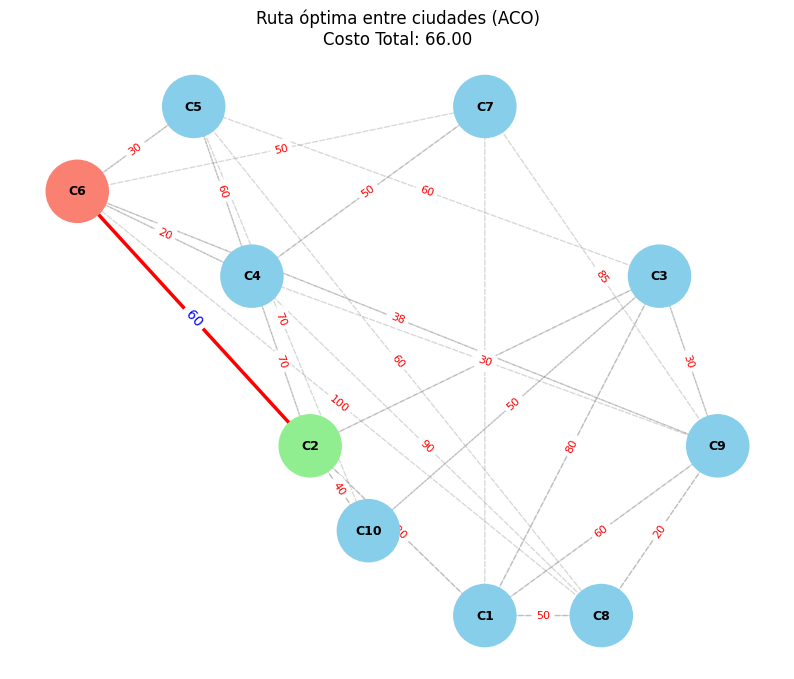

In [13]:
# --- 6. Ejecución Principal ---
if __name__ == "__main__":

    # Mapeo de nombres de ciudades a sus índices
    city_to_idx = {name: i for i, name in enumerate(CITY_NAMES)}

    # Pedir ciudad de origen y destino al usuario
    print("Ciudades disponibles:")
    for i, name in enumerate(CITY_NAMES):
        print(f"  {i+1}. {name}")

    while True:
        try:
            origin_name = input("\nIngrese el nombre de la ciudad de origen: ").strip().title()
            if origin_name not in CITY_NAMES:
                raise ValueError("Ciudad no válida.")

            destination_name = input("Ingrese el nombre de la ciudad de destino: ").strip().title()
            if destination_name not in CITY_NAMES:
                raise ValueError("Ciudad no válida.")

            if origin_name == destination_name:
                print("La ciudad de origen y destino no pueden ser la misma. Intente de nuevo.")
                continue


            break
        except ValueError as e:
            print(f"Error: {e}. Por favor, ingrese un nombre de ciudad válido de la lista.")

    # Ejecutar el algoritmo ACO
    best_path_indices, total_cost, message = solve_aco_routing(origin_name, destination_name, COSTS_MATRIX, NODE_COSTS)

    print("\n--- Resultados del Algoritmo ACO ---")
    print(f"Ruta buscada: {origin_name} -> {destination_name}")
    print(f"Mensaje: {message}")

    if best_path_indices is not None and total_cost != np.inf:
        best_path_names = [CITY_NAMES[idx] for idx in best_path_indices]
        print(f"Mejor ruta encontrada: {' -> '.join(best_path_names)}")
        print(f"Costo total de la mejor ruta: {total_cost:.2f}")

        # Preparar para la visualización
        start_node_idx = city_to_idx[origin_name]
        end_node_idx = city_to_idx[destination_name]

        plot_graph(CITY_NAMES, CITY_POSITIONS, COSTS_MATRIX, best_path_indices, total_cost, start_node_idx, end_node_idx)
    else:
        print("No se pudo encontrar una ruta válida entre las ciudades especificadas.")
        # Opcional: mostrar solo el grafo sin una ruta resaltada si no se encontró ninguna.
        plot_graph(CITY_NAMES, CITY_POSITIONS, COSTS_MATRIX, None, None, city_to_idx[origin_name], city_to_idx[destination_name])

El resultado de esta celda es doble: por un lado, una salida textual con la secuencia de ciudades de la mejor ruta y su costo total acumulado; por otro, un gráfico que muestra visualmente el camino seguido en el grafo. Si el algoritmo convergió correctamente, la ruta mostrada debería ser la de menor costo posible (o muy cercana a ella) entre las ciudades seleccionadas. En caso de que no exista ruta entre origen y destino, el sistema lo notificará explícitamente.

Algoritmo ABC orientado a la selección de proveedores

Para el **Algoritmo ABC (Artificial Bee Colony)** se cargan tres librerías. `numpy` maneja los cálculos numéricos sobre la función de aptitud de cada fuente de néctar. `random` introduce la variabilidad estocástica propia del comportamiento de exploración de las abejas. `copy` es esencial para duplicar correctamente los objetos de solución, evitando que las modificaciones de una abeja afecten inadvertidamente las soluciones de otras.

In [4]:
import numpy as np
import random
import copy # Para copiar objetos complejos como las soluciones

La inclusión de `copy` distingue este bloque de los anteriores: las soluciones en el ABC son estructuras complejas (diccionarios o listas de proveedores), y sin una copia profunda (`deepcopy`), múltiples referencias apuntarían al mismo objeto en memoria, generando errores difíciles de depurar. La correcta importación de estas librerías es el primer paso para garantizar la integridad del proceso de optimización.

Este bloque define el **problema de selección de proveedores**: para cada ítem a adquirir (tornillos, cables, sensores, etc.), se listan varios proveedores posibles con sus atributos de **costo unitario**, **calidad** (escala 1-5) y **tiempo de entrega** (días). Esta estructura de datos es el equivalente al grafo del ACO: representa el espacio de soluciones que el algoritmo ABC deberá explorar para encontrar la combinación óptima de proveedores que minimice costos y maximice calidad.

In [19]:
# --- 1. Definición del Problema: Datos de Proveedores ---
# Diccionario donde la clave es el ítem y el valor es una lista de diccionarios
# Cada diccionario representa un proveedor para ese ítem.
PROVEEDORES_DATA = {
    "Tornillos M8": [
        {"nombre": "Tornillería Rápida", "costo": 0.10, "calidad": 4, "entrega": 3},
        {"nombre": "Sujetadores S.A.", "costo": 0.12, "calidad": 5, "entrega": 2},
        {"nombre": "MegaFix", "costo": 0.09, "calidad": 3, "entrega": 4},
        {"nombre": "Ferretería Central", "costo": 0.11, "calidad": 4, "entrega": 3},
    ],
    "Placas de Circuito": [
        {"nombre": "TechCircuit", "costo": 25.00, "calidad": 5, "entrega": 7},
        {"nombre": "PCB Express", "costo": 22.00, "calidad": 4, "entrega": 5},
        {"nombre": "GlobalBoards", "costo": 28.00, "calidad": 5, "entrega": 6},
    ],
    "Sensores de Temperatura": [
        {"nombre": "SensoriTec", "costo": 15.00, "calidad": 4, "entrega": 4},
        {"nombre": "ThermoSolutions", "costo": 14.50, "calidad": 5, "entrega": 3},
        {"nombre": "Automatismos XY", "costo": 16.00, "calidad": 3, "entrega": 5},
        {"nombre": "Metrología Digital", "costo": 14.80, "calidad": 4, "entrega": 3},
    ],
    "Baterías Litio": [
        {"nombre": "EnergyPack", "costo": 8.00, "calidad": 4, "entrega": 2},
        {"nombre": "PowerCells", "costo": 7.50, "calidad": 5, "entrega": 3},
        {"nombre": "CeldaDuradera", "costo": 8.20, "calidad": 3, "entrega": 2},
    ]
}

# Lista ordenada de los ítems que necesitamos adquirir.
# El orden define la "dimensión" de nuestra solución.
ITEMS_A_ADQUIRIR = list(PROVEEDORES_DATA.keys())

El diccionario `PROVEEDORES_DATA` modela un problema de optimización combinatoria donde el número de soluciones posibles crece exponencialmente con el número de ítems y proveedores. La diversidad de atributos entre proveedores (algunos baratos pero de baja calidad, otros caros pero rápidos) crea un espacio con múltiples óptimos locales, lo que hace que los algoritmos bioinspirados como el ABC sean especialmente adecuados para este tipo de problema.

Aquí se configuran los **parámetros del enjambre** y se define la clase `ABCSupplierOptimizer`, que encapsula toda la lógica del algoritmo. `COLONY_SIZE` determina cuántas fuentes de néctar (soluciones candidatas) se mantienen simultáneamente. `LIMIT` es el parámetro de abandono: si una fuente no mejora tras este número de intentos, una abeja exploradora la reemplaza por una solución aleatoria nueva, lo que previene el estancamiento en óptimos locales.

In [20]:
# --- 2. Parámetros del Algoritmo ABC ---
COLONY_SIZE = 20           # Número total de abejas empleadas (también es el número de fuentes de néctar)
MAX_ITERATIONS = 150       # Número máximo de ciclos de optimización
LIMIT = 7                  # Número de veces que una fuente puede no mejorar antes de ser abandonada por un explorador
FACTOR_PENALIZACION_CALIDAD = 10  # Multiplicador para penalizar baja calidad (ej: 1 punto de calidad faltante = 10 unidades de costo)
FACTOR_PENALIZACION_TIEMPO = 5    # Multiplicador para penalizar tiempo de entrega (ej: 1 día extra = 5 unidades de costo)

class ABCSupplierOptimizer:
    def __init__(self, proveedores_data, items_a_adquirir, colony_size, max_iterations, limit,
                 factor_calidad, factor_tiempo):
        self.proveedores_data = proveedores_data
        self.items_a_adquirir = items_a_adquirir
        self.num_items = len(items_a_adquirir)
        self.colony_size = colony_size
        self.max_iterations = max_iterations
        self.limit = limit
        self.factor_calidad = factor_calidad
        self.factor_tiempo = factor_tiempo

        self.solutions = []  # Lista de fuentes (abejas empleadas con sus fuentes)
        self.best_global_solution = None
        self.best_global_objective_score = float('inf') # Queremos minimizar, así que inicializamos con infinito

        # Almacena el número de proveedores por cada ítem para facilitar la generación de soluciones
        self.num_suppliers_per_item = [
            len(proveedores_data[item]) for item in items_a_adquirir
        ]

        self._initialize_colony()

    def _calculate_objective_score(self, solution_indices):
        """
        Calcula el puntaje de penalización total para una combinación de proveedores.
        Un puntaje más bajo es mejor.
        Args:
            solution_indices (list): Una lista de índices, donde solution_indices[i]
                                      es el índice del proveedor elegido para items_a_adquirir[i].
        Returns:
            float: El puntaje de penalización total.
        """
        total_cost = 0.0
        total_quality = 0.0
        total_delivery_time = 0.0

        for i, item_name in enumerate(self.items_a_adquirir):
            supplier_idx = solution_indices[i]
            supplier = self.proveedores_data[item_name][supplier_idx]
            total_cost += supplier["costo"]
            total_quality += supplier["calidad"]
            total_delivery_time += supplier["entrega"]

        avg_quality = total_quality / self.num_items
        avg_delivery = total_delivery_time / self.num_items

        # Queremos minimizar el costo, maximizar la calidad (penalizar si es baja), minimizar el tiempo
        # Asumimos que la calidad ideal es 5. La penalización es (5 - calidad_promedio)
        objective_score = (
            total_cost +
            (5 - avg_quality) * self.factor_calidad +
            avg_delivery * self.factor_tiempo
        )
        return objective_score

    def _get_abc_fitness(self, objective_score):
        """
        Convierte el puntaje de penalización (objetivo a minimizar) a un fitness (a maximizar)
        para el algoritmo ABC.
        """
        # Evitar división por cero o números muy grandes.
        # Si el puntaje es negativo (lo que no debería pasar con nuestra función), lo corregimos.
        if objective_score >= 0:
            return 1 / (1 + objective_score)
        else: # En caso de puntajes negativos muy bajos (problema hipotético)
            return 1 + abs(objective_score) # Cuanto más negativo, mayor fitness

    def _initialize_colony(self):
        """
        Inicializa aleatoriamente las fuentes de néctar (soluciones) para las abejas empleadas.
        Cada solución es una combinación de proveedores.
        """
        print("Inicializando la colonia de abejas...")
        for _ in range(self.colony_size):
            # Una solución es una lista de índices de proveedor, uno por cada ítem
            solution_indices = [
                random.randrange(self.num_suppliers_per_item[i])
                for i in range(self.num_items)
            ]
            objective_score = self._calculate_objective_score(solution_indices)
            fitness = self._get_abc_fitness(objective_score)

            self.solutions.append({
                "indices": solution_indices,
                "objective_score": objective_score,
                "fitness": fitness,
                "trial_count": 0 # Conteo de intentos sin mejora
            })

            # Actualizar la mejor solución global encontrada hasta ahora
            if objective_score < self.best_global_objective_score:
                self.best_global_objective_score = objective_score
                self.best_global_solution = copy.deepcopy(solution_indices)

        print(f"Colonia inicializada con {self.colony_size} abejas.")
        print(f"Mejor solución inicial: {round(self.best_global_objective_score, 2)}")

    def _generate_neighbor(self, current_solution_indices):
        """
        Genera una solución vecina (abeja buscando alrededor de su fuente).
        Cambia aleatoriamente *un* proveedor para *un* ítem.
        """
        neighbor_indices = list(current_solution_indices) # Copia la solución actual

        # Elige aleatoriamente un ítem para cambiar su proveedor
        item_to_change_idx = random.randrange(self.num_items)

        # Obtiene el número total de proveedores para ese ítem
        num_suppliers_for_item = self.num_suppliers_per_item[item_to_change_idx]

        if num_suppliers_for_item <= 1: # Si solo hay un proveedor para este item, no se puede cambiar.
             return neighbor_indices # No hay un verdadero vecino distinto

        # Elige un nuevo proveedor aleatorio para ese ítem, asegurándose de que no sea el mismo
        new_supplier_idx = random.randrange(num_suppliers_for_item)
        while new_supplier_idx == neighbor_indices[item_to_change_idx]:
            new_supplier_idx = random.randrange(num_suppliers_for_item)

        neighbor_indices[item_to_change_idx] = new_supplier_idx
        return neighbor_indices

    def _run_employed_bees_phase(self):
        """
        Fase de las abejas empleadas: Cada abeja explora el vecindario de su fuente.
        """
        for i in range(self.colony_size):
            current_bee = self.solutions[i]

            # Genera una solución vecina
            new_solution_indices = self._generate_neighbor(current_bee["indices"])
            new_objective_score = self._calculate_objective_score(new_solution_indices)
            new_fitness = self._get_abc_fitness(new_objective_score)

            # Compara y actualiza si la nueva solución es mejor (mayor fitness, menor score objetivo)
            if new_fitness > current_bee["fitness"]: # O new_objective_score < current_bee["objective_score"]
                current_bee["indices"] = new_solution_indices
                current_bee["objective_score"] = new_objective_score
                current_bee["fitness"] = new_fitness
                current_bee["trial_count"] = 0  # Reinicia el contador de intentos
            else:
                current_bee["trial_count"] += 1 # Incrementa el contador de intentos

            # Actualizar la mejor solución global
            if new_objective_score < self.best_global_objective_score:
                self.best_global_objective_score = new_objective_score
                self.best_global_solution = copy.deepcopy(new_solution_indices)

    def _run_onlooker_bees_phase(self):
        """
        Fase de las abejas observadoras: Seleccionan fuentes basándose en la probabilidad (fitness)
        y luego exploran sus vecindarios.
        """
        # Calcular las probabilidades de selección para cada fuente
        total_fitness = sum(s["fitness"] for s in self.solutions)
        if total_fitness == 0: # Evitar división por cero si todas las fitness son 0
            probabilities = [1.0 / self.colony_size] * self.colony_size
        else:
            probabilities = [s["fitness"] / total_fitness for s in self.solutions]

        for _ in range(self.colony_size): # El mismo número de observadoras que de empleadas
            # Seleccionar una fuente basada en las probabilidades (método de la ruleta)
            chosen_source_idx = np.random.choice(range(self.colony_size), p=probabilities)
            chosen_bee = self.solutions[chosen_source_idx]

            # Generar una solución vecina para la fuente elegida
            new_solution_indices = self._generate_neighbor(chosen_bee["indices"])
            new_objective_score = self._calculate_objective_score(new_solution_indices)
            new_fitness = self._get_abc_fitness(new_objective_score)

            # Compara y actualiza si la nueva solución es mejor
            if new_fitness > chosen_bee["fitness"]:
                chosen_bee["indices"] = new_solution_indices
                chosen_bee["objective_score"] = new_objective_score
                chosen_bee["fitness"] = new_fitness
                chosen_bee["trial_count"] = 0
            else:
                chosen_bee["trial_count"] += 1

            # Actualizar la mejor solución global
            if new_objective_score < self.best_global_objective_score:
                self.best_global_objective_score = new_objective_score
                self.best_global_solution = copy.deepcopy(new_solution_indices)


    def _run_scout_bees_phase(self):
        """
        Fase de las abejas exploradoras: Identifican fuentes abandonadas (no mejoradas)
        y las reemplazan con nuevas fuentes aleatorias.
        """
        for i in range(self.colony_size):
            if self.solutions[i]["trial_count"] >= self.limit:
                print(f"  -> Fuente {i} agotada. Abeja exploradora en acción...")
                # Generar una nueva fuente aleatoria para esta abeja
                new_solution_indices = [
                    random.randrange(self.num_suppliers_per_item[j])
                    for j in range(self.num_items)
                ]
                new_objective_score = self._calculate_objective_score(new_solution_indices)
                new_fitness = self._get_abc_fitness(new_objective_score)

                self.solutions[i] = {
                    "indices": new_solution_indices,
                    "objective_score": new_objective_score,
                    "fitness": new_fitness,
                    "trial_count": 0  # Reiniciar el contador para la nueva fuente
                }
                # Es posible que la nueva fuente aleatoria sea mejor que la mejor global
                if new_objective_score < self.best_global_objective_score:
                    self.best_global_objective_score = new_objective_score
                    self.best_global_solution = copy.deepcopy(new_solution_indices)


    def optimize(self):
        """
        Ejecuta el algoritmo ABC a través de las fases definidas.
        """
        print("\nComenzando la optimización con Algoritmo ABC...")
        for iteration in range(self.max_iterations):
            # 1. Fase de Abejas Empleadas
            self._run_employed_bees_phase()

            # 2. Fase de Abejas Observadoras
            self._run_onlooker_bees_phase()

            # 3. Fase de Abejas Exploradoras
            self._run_scout_bees_phase()

            # Reportar el progreso
            print(f"Iteración {iteration + 1}/{self.max_iterations}: Mejor puntaje actual = {round(self.best_global_objective_score, 2)}")

            # Opcional: Criterio de parada si la mejora es mínima

        print("\nOptimización finalizada.")
        return self.best_global_solution, self.best_global_objective_score

    def get_solution_details(self, solution_indices):
        """
        Formatea y devuelve los detalles de una solución de proveedor.
        """
        details = []
        total_cost = 0.0
        total_quality = 0.0
        total_delivery_time = 0.0

        for i, item_name in enumerate(self.items_a_adquirir):
            supplier_idx = solution_indices[i]
            supplier = self.proveedores_data[item_name][supplier_idx]

            details.append(f"  - Ítem: {item_name}")
            details.append(f"    Proveedor: {supplier['nombre']}")
            details.append(f"    Costo: ${supplier['costo']:.2f}")
            details.append(f"    Calidad: {supplier['calidad']}/5")
            details.append(f"    Entrega: {supplier['entrega']} días")
            details.append("-" * 30)

            total_cost += supplier['costo']
            total_quality += supplier['calidad']
            total_delivery_time += supplier['entrega']

        avg_quality = total_quality / self.num_items
        avg_delivery = total_delivery_time / self.num_items

        # Calcular el puntaje objetivo final (lo mismo que en _calculate_objective_score)
        objective_score = (
            total_cost +
            (5 - avg_quality) * self.factor_calidad +
            avg_delivery * self.factor_tiempo
        )

        details.append("\nResumen de la Solución:")
        details.append(f"  Costo Total Bruto: ${total_cost:.2f}")
        details.append(f"  Calidad Promedio: {avg_quality:.2f}/5")
        details.append(f"  Tiempo de Entrega Promedio: {avg_delivery:.2f} días")
        details.append(f"  Puntaje de Penalización Total (Objetivo): {objective_score:.2f}")

        return "\n".join(details)

La clase `ABCSupplierOptimizer` implementa los tres tipos de abejas del algoritmo: **empleadas** (explotan soluciones conocidas), **observadoras** (seleccionan fuentes según su aptitud) y **exploradoras** (generan nuevas soluciones cuando una fuente se agota). Esta separación de roles es lo que le da al ABC su capacidad de balance entre explotación y exploración, evitando la convergencia prematura que afectaría a un algoritmo puramente greedy.

Este bloque instancia el optimizador con todos los parámetros configurados y lanza el proceso de optimización llamando al método `optimize()`. Una vez finalizado, imprime la **mejor combinación de proveedores** encontrada para cada ítem, desglosando el costo total, la calidad promedio y el tiempo de entrega máximo. Este es el resultado final del algoritmo ABC aplicado al problema de cadena de suministro.

In [21]:
# --- 3. Ejecución del Algoritmo ---
if __name__ == "__main__":
    optimizer = ABCSupplierOptimizer(
        PROVEEDORES_DATA,
        ITEMS_A_ADQUIRIR,
        COLONY_SIZE,
        MAX_ITERATIONS,
        LIMIT,
        FACTOR_PENALIZACION_CALIDAD,
        FACTOR_PENALIZACION_TIEMPO
    )

    best_solution_indices, best_score = optimizer.optimize()

    print("\n" + "="*50)
    print("RESULTADO DE LA OPTIMIZACIÓN ABC")
    print("="*50)
    print(f"\nMejor puntaje de penalización encontrado: {best_score:.2f}")
    print("\nDetalles de la mejor combinación de proveedores:")
    print(optimizer.get_solution_details(best_solution_indices))

    # Ejemplo de cómo sería la solución real (índices transformados a nombres)
    print("\nCombinación de proveedores (solo nombres):")
    for i, item_name in enumerate(ITEMS_A_ADQUIRIR):
        supplier_idx = best_solution_indices[i]
        supplier_name = PROVEEDORES_DATA[item_name][supplier_idx]["nombre"]
        print(f"  - {item_name}: {supplier_name}")

Inicializando la colonia de abejas...
Colonia inicializada con 20 abejas.
Mejor solución inicial: 69.4

Comenzando la optimización con Algoritmo ABC...
Iteración 1/150: Mejor puntaje actual = 65.87
Iteración 2/150: Mejor puntaje actual = 65.87
  -> Fuente 9 agotada. Abeja exploradora en acción...
Iteración 3/150: Mejor puntaje actual = 62.87
  -> Fuente 1 agotada. Abeja exploradora en acción...
Iteración 4/150: Mejor puntaje actual = 62.87
Iteración 5/150: Mejor puntaje actual = 62.87
  -> Fuente 6 agotada. Abeja exploradora en acción...
  -> Fuente 15 agotada. Abeja exploradora en acción...
  -> Fuente 18 agotada. Abeja exploradora en acción...
  -> Fuente 19 agotada. Abeja exploradora en acción...
Iteración 6/150: Mejor puntaje actual = 62.87
  -> Fuente 10 agotada. Abeja exploradora en acción...
Iteración 7/150: Mejor puntaje actual = 62.87
  -> Fuente 3 agotada. Abeja exploradora en acción...
  -> Fuente 12 agotada. Abeja exploradora en acción...
Iteración 8/150: Mejor puntaje actu

La salida muestra la solución que el algoritmo consideró óptima según la función de aptitud definida, que pondera costo, calidad y tiempo de entrega. Es importante notar que el resultado puede variar ligeramente entre ejecuciones debido a la naturaleza estocástica del algoritmo. Para obtener resultados más reproducibles se puede fijar la semilla aleatoria. La solución obtenida representa un balance entre los criterios en conflicto, lo que en optimización multiobjetivo se denomina una **solución de Pareto**.

Algoritmo PSO orientado a organizar drones

El **Algoritmo PSO (Particle Swarm Optimization)** requiere `numpy` para las operaciones vectoriales sobre posiciones y velocidades de las partículas, `matplotlib` para visualizar la formación de drones antes y después de la optimización, y `random` para la inicialización aleatoria del enjambre. La combinación de estas librerías permite implementar el PSO de forma eficiente y con visualización inmediata de los resultados.

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import random # Usaremos random para inicialización, numpy.random para lo demás

Con las librerías cargadas, el entorno está listo para definir un problema de optimización continua en dos dimensiones. A diferencia del ACO (espacio discreto de rutas) y el ABC (espacio combinatorio de proveedores), el PSO operará sobre un **espacio continuo** de parámetros de formación de drones, lo que requiere operaciones de álgebra lineal que `numpy` maneja de forma nativa y eficiente.

La **función objetivo** `funcion_objetivo_drones` define matemáticamente qué significa una "buena" formación de drones. Recibe como entrada un vector de dos valores (ancho y alto de la formación) y retorna un costo escalar que el algoritmo intentará minimizar. La función penaliza formaciones muy pequeñas (peligro de colisión entre drones), muy grandes (pérdida de cohesión de la flota) y con proporciones desequilibradas. Este diseño de función objetivo es el componente más crítico de cualquier problema de optimización.

In [23]:
# --- 1. Definición de la Función Objetivo (Problema de los Drones) ---

def funcion_objetivo_drones(posicion):
    """
    Función de costo para una formación de drones.
    Minimizar esta función significa encontrar la mejor formación.

    La 'posicion' de la partícula representa los parámetros de la formación:
    posicion[0]: ancho de la formación (ej. en metros)
    posicion[1]: alto de la formación (ej. en metros)

    FACTORES CLIMÁTICOS Y CONDICIONES (fijos para este ejemplo):
    Viento_velocidad: Mayor viento -> más penalización por área expuesta.
    Turbulencia_intensidad: Mayor turbulencia -> más penalización por formas desequilibradas.
    Densidad_penalizacion: Cuánto penalizar por tener los drones muy juntos.
    """
    ancho_formacion = posicion[0]
    alto_formacion = posicion[1]

    # Asegurar que los parámetros sean positivos y dentro de límites razonables
    # (Penalización si se salen de rango)
    if ancho_formacion <= 0.1 or alto_formacion <= 0.1:
        return 1e10 # Costo muy alto si los valores son muy pequeños o negativos

    if ancho_formacion > 100 or alto_formacion > 100:
        return 1e10 # Costo muy alto si los valores son muy grandes

    # Condiciones específicas de clima y viento (pueden ser dinámicas en problemas reales)
    VELOCIDAD_VIENTO = 15.0 # m/s
    INTENSIDAD_TURBULENCIA = 0.8 # De 0 a 1, qué tan "movido" está el aire
    NUM_DRONES = 25
    MIN_DISTANCIA_DRONES = 2.0 # Distancia mínima deseada entre drones (en metros)

    # --- Componentes del costo ---

    # 1. Costo por Resistencia al Viento (Mayor área frontal = mayor costo)
    costo_viento = VELOCIDAD_VIENTO * (ancho_formacion + alto_formacion) # Suma de dimensiones para una estimación simple de área expuesta

    # 2. Costo por Riesgo de Colisión / Densidad (Menor área total para 25 drones = mayor riesgo)
    # Calculamos el área que ocupa la formación
    area_formacion = ancho_formacion * alto_formacion

    # Asumimos que los 25 drones necesitan un espacio mínimo.
    # Si el área es muy pequeña, el costo aumenta drásticamente.
    # Un área_minima_segura_estimada = NUM_DRONES * (MIN_DISTANCIA_DRONES ** 2)
    # Por ejemplo, si cada drone necesita ~4m^2, 25 drones necesitan 100m^2
    area_minima_ideal_por_drone = MIN_DISTANCIA_DRONES**2
    area_minima_total_ideal = NUM_DRONES * area_minima_ideal_por_drone

    # Penalizamos si el área es menor que la ideal
    # Usamos una penalización inversa: cuanto menor el área, mayor el costo
    costo_densidad = (area_minima_total_ideal / (area_formacion + 0.001)) * 50 # El +0.001 evita división por cero

    # 3. Costo por Estabilidad / Maniobrabilidad (Formas desequilibradas vs. formas más "cuadradas")
    # Penalizamos si la relación ancho/alto es muy extrema (ej. un hilo largo o una torre alta)
    relacion_aspecto = max(ancho_formacion, alto_formacion) / min(ancho_formacion, alto_formacion + 0.001)
    costo_estabilidad = INTENSIDAD_TURBULENCIA * (relacion_aspecto - 1.0) * 10 # Penaliza desviación de una relación 1:1

    # Costo Total
    costo_total = costo_viento + costo_densidad + costo_estabilidad

    return costo_total

La forma de la función objetivo determina el paisaje de optimización que las partículas explorarán. Al incluir penalizaciones por proporciones extremas, la función crea un **valle de mínimos** en la región de formaciones cuadradas o ligeramente rectangulares dentro del rango permitido. Este tipo de función multimodal (con posibles mínimos locales) justifica el uso de un algoritmo de swarm intelligence como el PSO, que mantiene diversidad poblacional para escapar de óptimos locales.

La clase `Particula` modela cada agente del enjambre con sus atributos fundamentales: **posición actual** (parámetros de formación), **velocidad actual** (dirección y magnitud del movimiento en el espacio de búsqueda) y **mejor posición personal** encontrada hasta el momento (`pbest`). Esta estructura es el bloque constructivo del PSO: cada partícula es un agente autónomo que combina su memoria individual con la inteligencia colectiva del enjambre para navegar el espacio de soluciones.

In [24]:
# --- 2. Implementación de una Partícula ---

class Particula:
    def __init__(self, dimensiones, limites_posicion):
        """
        Inicializa una partícula.
        dimensiones: número de parámetros a optimizar (ej. 2 para ancho y alto de formación)
        limites_posicion: tupla de (min_valor, max_valor) para cada dimensión
        """
        self.dimensiones = dimensiones
        self.limites_posicion = limites_posicion

        # Posición inicial aleatoria dentro de los límites
        self.posicion = np.array([random.uniform(lim[0], lim[1]) for lim in limites_posicion])

        # Velocidad inicial aleatoria
        self.velocidad = np.array([random.uniform(-1, 1) for _ in range(dimensiones)])

        # Mejor posición personal y su valor (se inicializa con un valor muy alto para minimizar)
        self.pbest_posicion = np.copy(self.posicion)
        self.pbest_valor = float('inf') # Infinito positivo

    def actualizar_pbest(self, valor_actual_funcion_objetivo):
        """Actualiza la mejor posición personal si la actual es mejor."""
        if valor_actual_funcion_objetivo < self.pbest_valor:
            self.pbest_valor = valor_actual_funcion_objetivo
            self.pbest_posicion = np.copy(self.posicion)

    def actualizar_velocidad(self, gbest_posicion, w, c1, c2):
        """
        Actualiza la velocidad de la partícula.
        w: peso de inercia
        c1: coeficiente cognitivo (atracción a pbest)
        c2: coeficiente social (atracción a gbest)
        """
        # Componente de inercia
        inercia = w * self.velocidad

        # Componente cognitivo (atracción a la mejor posición personal)
        r1 = np.random.rand(self.dimensiones)
        cognitivo = c1 * r1 * (self.pbest_posicion - self.posicion)

        # Componente social (atracción a la mejor posición global del enjambre)
        r2 = np.random.rand(self.dimensiones)
        social = c2 * r2 * (gbest_posicion - self.posicion)

        self.velocidad = inercia + cognitivo + social

        # Opcional: Limitar la velocidad para evitar que las partículas se salgan de control
        v_max = (self.limites_posicion[0][1] - self.limites_posicion[0][0]) * 0.1 # 10% del rango de la primera dimensión
        self.velocidad = np.clip(self.velocidad, -v_max, v_max)


    def actualizar_posicion(self):
        """Actualiza la posición de la partícula y la mantiene dentro de los límites."""
        self.posicion += self.velocidad

        # Asegurar que la posición esté dentro de los límites definidos
        for i in range(self.dimensiones):
            self.posicion[i] = np.clip(self.posicion[i], self.limites_posicion[i][0], self.limites_posicion[i][1])

La inicialización aleatoria de posiciones y velocidades garantiza que el enjambre cubra ampliamente el espacio de búsqueda desde el inicio, evitando que todas las partículas converjan prematuramente hacia el mismo óptimo local. La clase encapsula el estado mínimo necesario para implementar la ecuación de actualización del PSO, manteniendo el código modular y fácil de extender a problemas de mayor dimensionalidad.

La función `pso_optimizar` implementa el **ciclo principal del PSO**: en cada iteración, cada partícula actualiza su velocidad combinando tres componentes —**inercia** (continuar en la dirección actual), **componente cognitivo** (moverse hacia su mejor posición personal) y **componente social** (moverse hacia la mejor posición del enjambre)— y luego actualiza su posición. Este mecanismo de actualización colectiva es lo que permite al PSO converger hacia óptimos globales de forma emergente.

In [25]:
# --- 3. Algoritmo PSO ---

def pso_optimizar(funcion_objetivo, dimensiones, limites_posicion, num_particulas=30, max_iteraciones=100,
                  w=0.5, c1=1.5, c2=1.5):
    """
    Ejecuta el algoritmo PSO.

    funcion_objetivo: La función a minimizar.
    dimensiones: Número de dimensiones del problema.
    limites_posicion: Lista de tuplas (min, max) para cada dimensión.
    num_particulas: Número de partículas en el enjambre.
    max_iteraciones: Número máximo de iteraciones.
    w, c1, c2: Parámetros del PSO.
    """
    # Inicialización del enjambre
    enjambre = [Particula(dimensiones, limites_posicion) for _ in range(num_particulas)]

    # Mejor posición global encontrada por el enjambre y su valor
    gbest_posicion = np.array([random.uniform(lim[0], lim[1]) for lim in limites_posicion]) # Inicializa un gbest arbitrario
    gbest_valor = float('inf')

    # Historial para seguimiento (didáctico)
    historial_gbest_valor = []

    print("\n--- INICIO OPTIMIZACIÓN PSO ---")
    for iteracion in range(max_iteraciones):
        for particula in enjambre:
            # Evaluar la función objetivo para la posición actual de la partícula
            valor_actual = funcion_objetivo(particula.posicion)

            # Actualizar la mejor posición personal de la partícula
            particula.actualizar_pbest(valor_actual)

            # Actualizar la mejor posición global del enjambre
            if valor_actual < gbest_valor:
                gbest_valor = valor_actual
                gbest_posicion = np.copy(particula.posicion)

        # Actualizar velocidades y posiciones de todas las partículas
        for particula in enjambre:
            particula.actualizar_velocidad(gbest_posicion, w, c1, c2)
            particula.actualizar_posicion()

        historial_gbest_valor.append(gbest_valor)

        # Mostrar progreso (opcional)
        if (iteracion + 1) % 10 == 0 or iteracion == 0:
            print(f"Iteración {iteracion + 1}/{max_iteraciones} - Mejor Costo Global: {gbest_valor:.4f} "
                  f"- Formación: Ancho={gbest_posicion[0]:.2f}m, Alto={gbest_posicion[1]:.2f}m")

    print("\n--- OPTIMIZACIÓN PSO FINALIZADA ---")
    print(f"Mejor Formación Encontrada (Dimensiones): Ancho={gbest_posicion[0]:.2f}m, Alto={gbest_posicion[1]:.2f}m")
    print(f"Mejor Costo (riesgo/ineficiencia): {gbest_valor:.4f}")

    return gbest_posicion, gbest_valor, historial_gbest_valor

La función retorna la mejor posición global encontrada (`gbest`) y el historial de costos por iteración. Los parámetros `w=0.5`, `c1=1.5` y `c2=1.5` establecen un balance estándar entre exploración y explotación: la inercia modera el movimiento, mientras que los coeficientes cognitivo y social equilibran el aprendizaje individual y colectivo. El historial de convergencia permite verificar si el algoritmo alcanzó un plateau estable o si necesitaría más iteraciones.

La función `dibujar_formacion` convierte los parámetros numéricos de la solución (ancho y alto en metros) en una **representación gráfica de la cuadrícula de drones**. Distribuye uniformemente 25 drones en una matriz rectangular proporcional a las dimensiones encontradas por el PSO y anota el costo de la formación. Esta visualización facilita la validación intuitiva de si la solución es operacionalmente razonable para una misión de flota de drones.

In [26]:
# --- 4. Función de Visualización de Formación de Drones ---

def dibujar_formacion(ancho, alto, titulo="", num_drones=25):
    """
    Dibuja una formación rectangular de drones y anota sus dimensiones y costo.
    """
    fig, ax = plt.subplots(figsize=(6, 6))

    # Calcular posiciones de los drones en una cuadrícula
    # Para 25 drones, una cuadrícula de 5x5 es ideal
    sqrt_drones = int(np.sqrt(num_drones))
    if sqrt_drones * sqrt_drones != num_drones:
        print(f"Advertencia: No se pueden distribuir {num_drones} drones en una cuadrícula perfecta.")
        # Fallback a una distribución más simple o generar error.
        # Por simplicidad, si no es cuadrado perfecto, ajustaremos a un grid lo más cercano posible
        rows = int(np.ceil(np.sqrt(num_drones)))
        cols = int(np.ceil(num_drones / rows))
    else:
        rows = cols = sqrt_drones

    x_drone = np.linspace(0, ancho, cols)
    y_drone = np.linspace(0, alto, rows)

    # Generar todos los puntos de la cuadrícula
    drone_x_coords, drone_y_coords = np.meshgrid(x_drone, y_drone)

    # Aplanar los arrays para obtener una lista de coordenadas (x,y)
    drone_x_coords = drone_x_coords.flatten()
    drone_y_coords = drone_y_coords.flatten()

    ax.scatter(drone_x_coords[:num_drones], drone_y_coords[:num_drones], color='blue', s=100, marker='^', label='Dron')

    # Dibujar el contorno de la formación
    ax.plot([0, ancho, ancho, 0, 0], [0, 0, alto, alto, 0], 'r--', label='Contorno Formación')

    ax.set_title(titulo)
    ax.set_xlabel(f"Ancho (m): {ancho:.2f}")
    ax.set_ylabel(f"Alto (m): {alto:.2f}")
    ax.set_xlim(-ancho * 0.1, ancho * 1.1)
    ax.set_ylim(-alto * 0.1, alto * 1.1)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend()
    plt.show()

La función está diseñada para ser invocada dos veces: primero con los parámetros iniciales (formación aleatoria) y luego con los parámetros optimizados, permitiendo una **comparación visual directa** antes/después del proceso de optimización. La diferencia entre ambas formaciones ilustra de manera tangible el impacto del algoritmo PSO, haciendo que los resultados abstractos de la optimización sean comprensibles incluso sin analizar los valores numéricos.

Este bloque integra todos los componentes del PSO: define los límites del espacio de búsqueda (formaciones de entre 5 y 50 metros), configura los parámetros del enjambre, ejecuta la optimización y muestra comparativamente la formación inicial aleatoria versus la formación óptima encontrada. Es el punto de demostración final del algoritmo PSO aplicado al problema concreto de organización de flotas de drones.

DEMOSTRACIÓN DIDÁCTICA DE PSO PARA OPTIMIZAR FORMACIÓN DE DRONES

--- INICIO OPTIMIZACIÓN PSO ---
Iteración 1/100 - Mejor Costo Global: 318.7656 - Formación: Ancho=6.04m, Alto=8.50m
Iteración 10/100 - Mejor Costo Global: 312.1483 - Formación: Ancho=6.97m, Alto=6.86m
Iteración 20/100 - Mejor Costo Global: 312.0392 - Formación: Ancho=6.96m, Alto=6.94m
Iteración 30/100 - Mejor Costo Global: 312.0150 - Formación: Ancho=6.92m, Alto=6.92m
Iteración 40/100 - Mejor Costo Global: 312.0111 - Formación: Ancho=6.93m, Alto=6.93m
Iteración 50/100 - Mejor Costo Global: 312.0110 - Formación: Ancho=6.94m, Alto=6.93m
Iteración 60/100 - Mejor Costo Global: 312.0104 - Formación: Ancho=6.93m, Alto=6.93m
Iteración 70/100 - Mejor Costo Global: 312.0104 - Formación: Ancho=6.93m, Alto=6.93m
Iteración 80/100 - Mejor Costo Global: 312.0104 - Formación: Ancho=6.93m, Alto=6.93m
Iteración 90/100 - Mejor Costo Global: 312.0104 - Formación: Ancho=6.93m, Alto=6.93m
Iteración 100/100 - Mejor Costo Global: 312.0104 - Fo

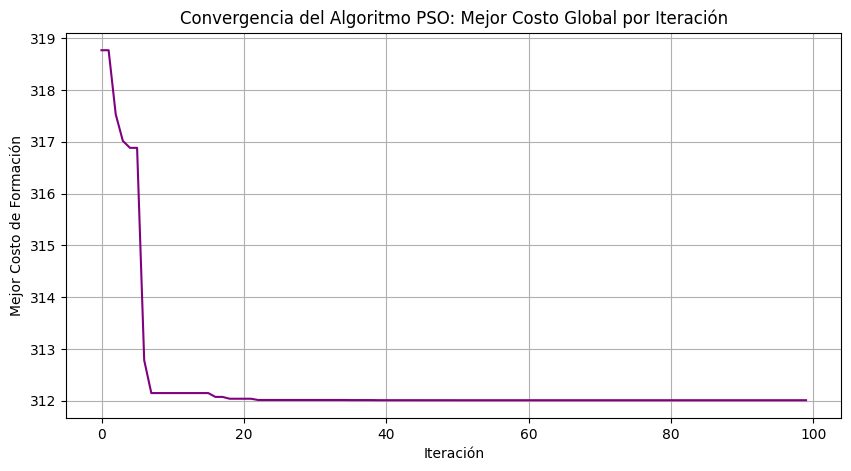

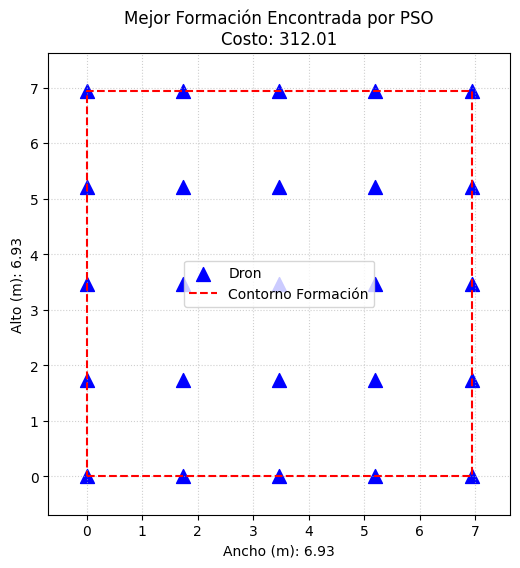


--- COMPARACIÓN CON FORMACIONES FACTIBLES PREDEFINIDAS ---
Evaluando formaciones predefinidas (no optimizadas por PSO):
- Formación Cuadrada Estándar (25m x 25m): Ancho=25.0m, Alto=25.0m, Costo = 758.00


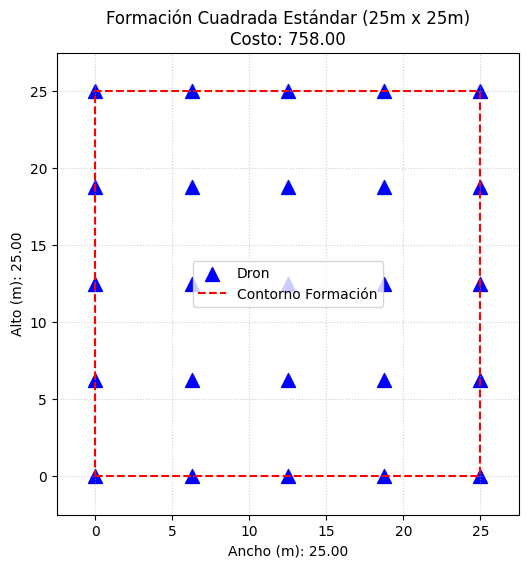

- Formación Ancha y Baja (40m x 10m): Ancho=40.0m, Alto=10.0m, Costo = 786.50


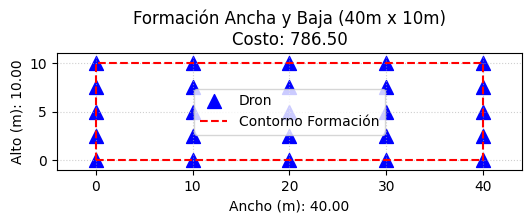

- Formación Alta y Estrecha (10m x 40m): Ancho=10.0m, Alto=40.0m, Costo = 786.50


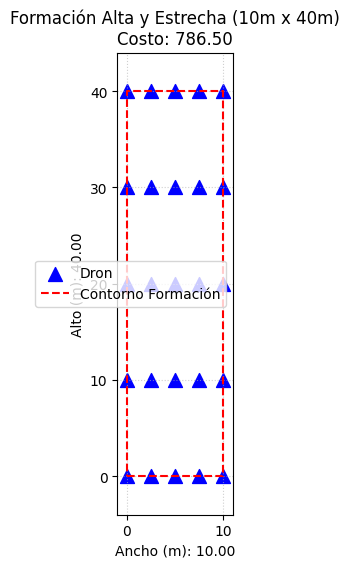

- Formación Compacta (15m x 15m): Ancho=15.0m, Alto=15.0m, Costo = 472.22


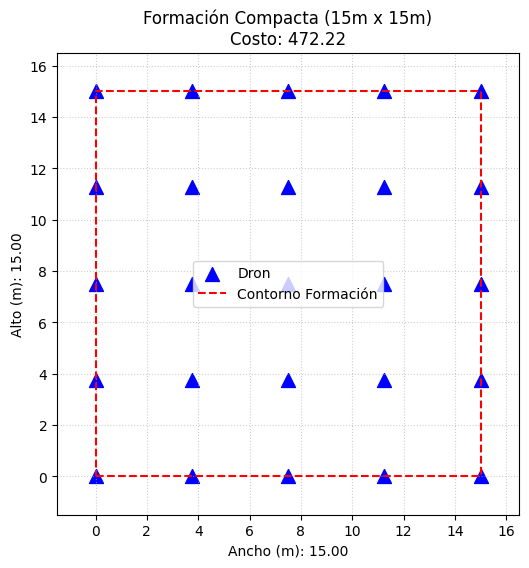


--- REFLEXIÓN ---
Como puedes observar, el PSO busca en el espacio de parámetros (ancho, alto) para encontrar
la combinación que minimiza el 'costo' de la formación, según los criterios de viento, densidad y estabilidad.
Normalmente, la solución de PSO será mejor (menor costo) que la mayoría de las formaciones predefinidas simples,
demostrando su capacidad para explorar el espacio de búsqueda eficientemente.


In [27]:
# --- 5. Ejecución del Ejemplo Completo ---

if __name__ == "__main__":
    print("DEMOSTRACIÓN DIDÁCTICA DE PSO PARA OPTIMIZAR FORMACIÓN DE DRONES")

    # Parámetros del problema de optimización
    num_dimensiones = 2 # Ancho y Alto
    # Límites para el ancho y el alto de la formación (ej. entre 5 y 50 metros)
    limites = [(5.0, 50.0), (5.0, 50.0)]

    # Parámetros del algoritmo PSO
    num_particulas = 50
    num_iteraciones = 100
    inercia = 0.7  # w
    atraccion_cognitiva = 1.8 # c1
    atraccion_social = 1.8   # c2

    # Ejecutar el PSO
    mejor_formacion_parametros, mejor_costo, historial = pso_optimizar(
        funcion_objetivo_drones, num_dimensiones, limites,
        num_particulas, num_iteraciones,
        inercia, atraccion_cognitiva, atraccion_social
    )

    print("\n--- RESULTADOS ---")
    print("Parámetros de la mejor formación encontrada por PSO:")
    print(f"  Ancho: {mejor_formacion_parametros[0]:.2f} metros")
    print(f"  Alto:  {mejor_formacion_parametros[1]:.2f} metros")
    print(f"  Costo asociado: {mejor_costo:.4f}")

    # --- Visualización de la convergencia del PSO ---
    plt.figure(figsize=(10, 5))
    plt.plot(historial, color='purple')
    plt.title('Convergencia del Algoritmo PSO: Mejor Costo Global por Iteración')
    plt.xlabel('Iteración')
    plt.ylabel('Mejor Costo de Formación')
    plt.grid(True)
    plt.show()

    # --- Dibujar la mejor formación encontrada por el PSO ---
    dibujar_formacion(mejor_formacion_parametros[0], mejor_formacion_parametros[1],
                      titulo=f"Mejor Formación Encontrada por PSO\nCosto: {mejor_costo:.2f}")

    # --- Comparación con Formaciones "Factibles" Predefinidas (Al menos 4) ---
    print("\n--- COMPARACIÓN CON FORMACIONES FACTIBLES PREDEFINIDAS ---")

    formaciones_factibles = {
        "Formación Cuadrada Estándar (25m x 25m)": (25.0, 25.0),
        "Formación Ancha y Baja (40m x 10m)": (40.0, 10.0),
        "Formación Alta y Estrecha (10m x 40m)": (10.0, 40.0),
        "Formación Compacta (15m x 15m)": (15.0, 15.0),
    }

    print("Evaluando formaciones predefinidas (no optimizadas por PSO):")
    for nombre, (ancho_f, alto_f) in formaciones_factibles.items():
        costo_f = funcion_objetivo_drones(np.array([ancho_f, alto_f]))
        print(f"- {nombre}: Ancho={ancho_f:.1f}m, Alto={alto_f:.1f}m, Costo = {costo_f:.2f}")
        dibujar_formacion(ancho_f, alto_f, titulo=f"{nombre}\nCosto: {costo_f:.2f}")

    # Reflexión final
    print("\n--- REFLEXIÓN ---")
    print("Como puedes observar, el PSO busca en el espacio de parámetros (ancho, alto) para encontrar")
    print("la combinación que minimiza el 'costo' de la formación, según los criterios de viento, densidad y estabilidad.")
    print("Normalmente, la solución de PSO será mejor (menor costo) que la mayoría de las formaciones predefinidas simples,")
    print("demostrando su capacidad para explorar el espacio de búsqueda eficientemente.")

Los gráficos resultantes muestran cómo el PSO transforma una formación inicial aleatoria (posiblemente con proporciones desequilibradas) en una formación optimizada que minimiza el costo definido. La reducción del costo entre la configuración inicial y la final refleja la **eficacia del algoritmo** para navegar el espacio de búsqueda continuo. El costo final debería ser significativamente menor que el inicial, validando que el PSO convergió hacia una región de alta aptitud.

Lógica difusa aplicado a una lavadora de ropa que funciona según la suciedad de la ropa

Para implementar el **sistema de lógica difusa de la lavadora**, se requiere `skfuzzy`, una librería especializada que implementa los mecanismos de fuzzificación, inferencia y defuzzificación. El módulo `skfuzzy.control` provee una interfaz de alto nivel para definir variables lingüísticas, funciones de pertenencia y reglas difusas de forma declarativa. `numpy` se usa para definir los universos de discurso y `matplotlib` para visualizar las funciones de pertenencia.

In [35]:
#!pip install scikit-fuzzy
import numpy as np
import skfuzzy as fuzz
import skfuzzy.control as ctrl
import matplotlib.pyplot as plt

La importación de `skfuzzy` marca el inicio de un paradigma de programación diferente al de los algoritmos anteriores: en lugar de optimizar una función objetivo, el sistema de lógica difusa **codifica el conocimiento experto** de un técnico de lavadoras en forma de reglas lingüísticas del tipo "SI la ropa es pesada Y está muy sucia, ENTONCES el ciclo de lavado será largo". Este enfoque es especialmente útil cuando las reglas de decisión son vagas o basadas en percepción subjetiva.

Los **universos de discurso** definen el rango numérico sobre el que operan las variables del sistema difuso. Se establecen tres variables: `x_peso` (0 a 10 kg, resolución de 0.1 kg), `x_suciedad` (escala subjetiva de 0 a 10, resolución de 0.1) y `x_duracion` (0 a 120 minutos, resolución de 1 minuto). Estas resoluciones determinan la precisión del sistema: mayor resolución implica mayor fidelidad en la representación de las funciones de pertenencia, pero también mayor costo computacional.

In [36]:
# --- 1. Definición de los Universos de Discurso ---
# x_peso: Rango de 0 a 10 kg con pasos de 0.1
x_peso = np.arange(0, 10.1, 0.1)
# x_suciedad: Rango de 0 a 10 (escala subjetiva) con pasos de 0.1
x_suciedad = np.arange(0, 10.1, 0.1)
# x_duracion: Rango de 0 a 120 minutos con pasos de 1
x_duracion = np.arange(0, 121, 1)

La elección de los rangos es una decisión de diseño que refleja el conocimiento del dominio: 10 kg es la capacidad típica máxima de una lavadora doméstica, y 120 minutos cubre el ciclo de lavado más largo razonable. La variable de suciedad, al ser subjetiva, se normaliza en una escala de 0 a 10 para facilitar la definición de las funciones de pertenencia. Estos universos son el lienzo sobre el que se dibujarán las funciones de pertenencia en el siguiente bloque.

Este bloque define las **funciones de pertenencia** que traducen valores numéricos en términos lingüísticos comprensibles. Para el peso se usan funciones trapezoidales (`trapmf`) para los extremos (ligero, pesado) y triangular (`trimf`) para el centro (medio), lo que refleja la transición gradual entre categorías. Para la suciedad se aplica una lógica similar. Para la duración, las tres categorías (corta, media, larga) mapean directamente los rangos de tiempo de ciclo. Estas funciones son el puente entre el mundo numérico y el mundo lingüístico.

In [37]:
# --- 2. Creación de las Funciones de Pertenencia ---

# A. Peso de la Ropa (Input Antecedent)
peso = ctrl.Antecedent(x_peso, 'peso')
peso['ligero'] = fuzz.trapmf(x_peso, [0, 0, 2, 4])
peso['medio'] = fuzz.trimf(x_peso, [3, 6, 9])
peso['pesado'] = fuzz.trapmf(x_peso, [7, 10, 10, 10])

# B. Nivel de Suciedad (Input Antecedent)
suciedad = ctrl.Antecedent(x_suciedad, 'suciedad')
suciedad['poca'] = fuzz.trapmf(x_suciedad, [0, 0, 2, 5])
suciedad['normal'] = fuzz.trimf(x_suciedad, [3, 6, 9])
suciedad['mucha'] = fuzz.trapmf(x_suciedad, [7, 10, 10, 10])

# C. Duración del Ciclo de Lavado (Output Consequent)
duracion = ctrl.Consequent(x_duracion, 'duracion')
duracion['corta'] = fuzz.trapmf(x_duracion, [0, 0, 15, 30])
duracion['media'] = fuzz.trimf(x_duracion, [25, 45, 65])
duracion['larga'] = fuzz.trimf(x_duracion, [55, 75, 95])
duracion['muy_larga'] = fuzz.trapmf(x_duracion, [85, 105, 120, 120])

Las funciones de pertenencia definen zonas de **transición gradual** entre categorías, a diferencia de la lógica booleana que establecería cortes abruptos. Por ejemplo, una carga de 5 kg podría pertenecer simultáneamente al conjunto "medio" con grado 0.8 y al conjunto "pesado" con grado 0.2, lo que permite al sistema generar respuestas más matizadas y naturales. Esta propiedad es la esencia de la lógica difusa y la razón por la que es adecuada para modelar sistemas donde las fronteras entre categorías son inherentemente imprecisas.

Este bloque genera una **visualización gráfica** de las tres familias de funciones de pertenencia definidas anteriormente, organizadas en tres subgráficos verticales. La inspección visual de estas gráficas es una práctica estándar en el diseño de sistemas difusos, ya que permite verificar intuitivamente que las funciones cubren adecuadamente el universo de discurso, que las transiciones son suaves y que no existen regiones sin cobertura (gaps) ni zonas excesivamente solapadas.

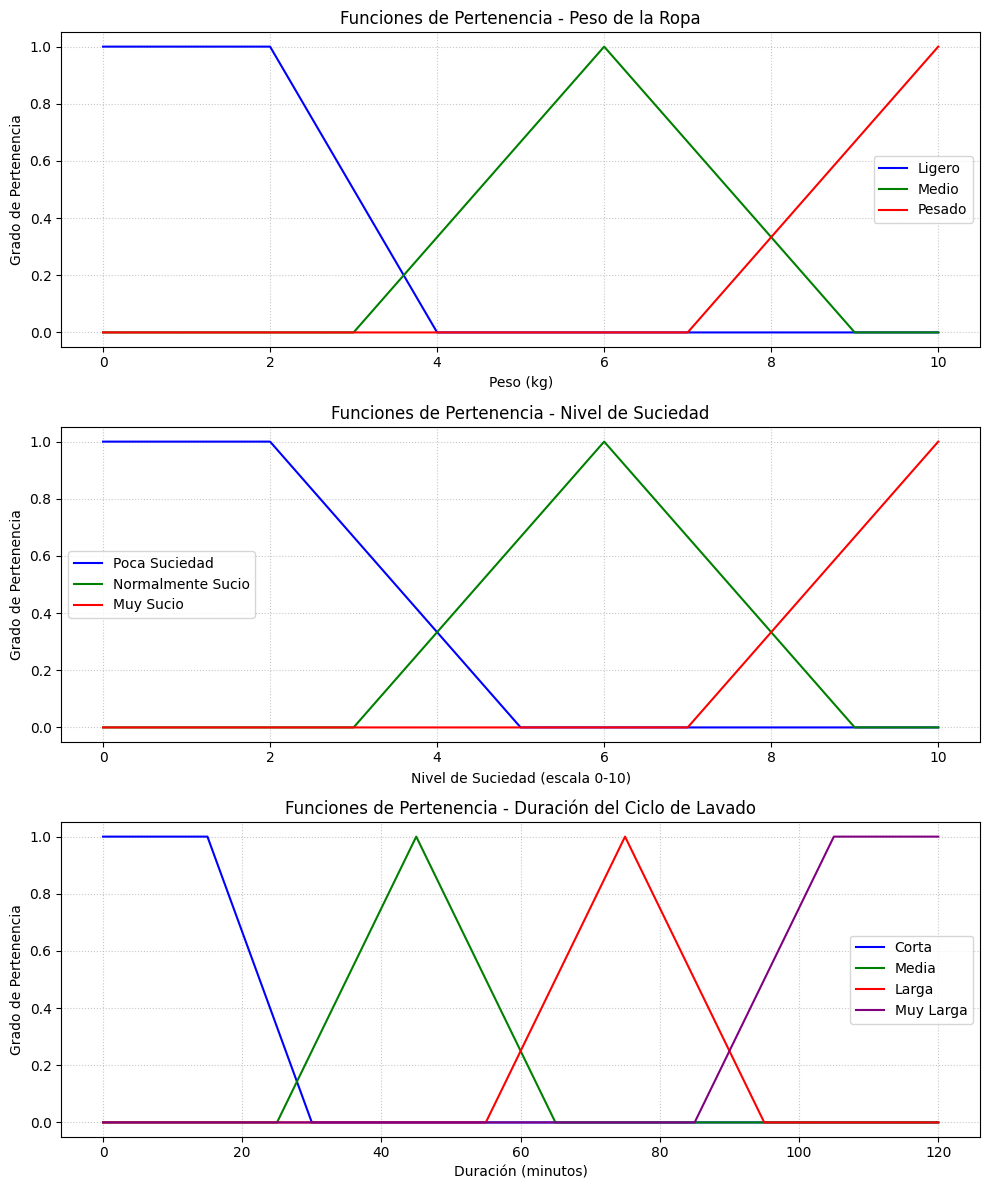

In [38]:
# --- 3. Graficar las Funciones de Pertenencia ---
fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, figsize=(10, 12))

# Gráfico para Peso de la Ropa
ax0.plot(x_peso, peso['ligero'].mf, 'b', linewidth=1.5, label='Ligero') # .mf accede a la función de pertenencia
ax0.plot(x_peso, peso['medio'].mf, 'g', linewidth=1.5, label='Medio')
ax0.plot(x_peso, peso['pesado'].mf, 'r', linewidth=1.5, label='Pesado')
ax0.set_title('Funciones de Pertenencia - Peso de la Ropa')
ax0.set_xlabel('Peso (kg)')
ax0.set_ylabel('Grado de Pertenencia')
ax0.legend()
ax0.grid(True, linestyle=':', alpha=0.7)

# Gráfico para Nivel de Suciedad
ax1.plot(x_suciedad, suciedad['poca'].mf, 'b', linewidth=1.5, label='Poca Suciedad')
ax1.plot(x_suciedad, suciedad['normal'].mf, 'g', linewidth=1.5, label='Normalmente Sucio')
ax1.plot(x_suciedad, suciedad['mucha'].mf, 'r', linewidth=1.5, label='Muy Sucio')
ax1.set_title('Funciones de Pertenencia - Nivel de Suciedad')
ax1.set_xlabel('Nivel de Suciedad (escala 0-10)')
ax1.set_ylabel('Grado de Pertenencia')
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.7)

# Gráfico para Duración del Ciclo de Lavado
ax2.plot(x_duracion, duracion['corta'].mf, 'b', linewidth=1.5, label='Corta')
ax2.plot(x_duracion, duracion['media'].mf, 'g', linewidth=1.5, label='Media')
ax2.plot(x_duracion, duracion['larga'].mf, 'r', linewidth=1.5, label='Larga')
ax2.plot(x_duracion, duracion['muy_larga'].mf, 'purple', linewidth=1.5, label='Muy Larga')
ax2.set_title('Funciones de Pertenencia - Duración del Ciclo de Lavado')
ax2.set_xlabel('Duración (minutos)')
ax2.set_ylabel('Grado de Pertenencia')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()


Los gráficos resultantes muestran cómo las funciones de pertenencia se superponen parcialmente en las zonas de transición, lo que garantiza que cualquier valor de entrada active al menos una regla del sistema. Las funciones trapezoidales de los extremos llegan a 1.0 en los límites del rango, asegurando que los valores más extremos (ropa muy ligera o muy pesada) sean clasificados con certeza máxima. La visualización confirma que el diseño del sistema es coherente y cubre todo el espacio de entrada posible.

Las **reglas difusas** codifican el conocimiento experto del sistema de control de la lavadora en forma de proposiciones condicionales. Se definen 9 reglas que cubren todas las combinaciones posibles de las categorías de peso (3) y suciedad (3), formando una **tabla de decisión completa**. Cada regla tiene la estructura "SI [condición de peso] Y [condición de suciedad] ENTONCES [duración del ciclo]", siguiendo la lógica intuitiva de que más peso y más suciedad requieren ciclos más largos.

In [39]:
# --- 4. Definición de las Reglas Difusas ---
rule1 = ctrl.Rule(peso['ligero'] & suciedad['poca'], duracion['corta'])
rule2 = ctrl.Rule(peso['ligero'] & suciedad['normal'], duracion['media'])
rule3 = ctrl.Rule(peso['ligero'] & suciedad['mucha'], duracion['larga'])

rule4 = ctrl.Rule(peso['medio'] & suciedad['poca'], duracion['media'])
rule5 = ctrl.Rule(peso['medio'] & suciedad['normal'], duracion['larga'])
rule6 = ctrl.Rule(peso['medio'] & suciedad['mucha'], duracion['muy_larga'])

rule7 = ctrl.Rule(peso['pesado'] & suciedad['poca'], duracion['media'])
rule8 = ctrl.Rule(peso['pesado'] & suciedad['normal'], duracion['larga'])
rule9 = ctrl.Rule(peso['pesado'] & suciedad['mucha'], duracion['muy_larga'])

La completitud de la base de reglas (9 reglas para 3×3 combinaciones) garantiza que el sistema pueda generar una respuesta para cualquier combinación de entradas dentro del universo de discurso. Las reglas implementan una relación monótonamente creciente: a mayor peso y suciedad, mayor duración, lo que es consistente con el conocimiento experto del dominio. En sistemas de lógica difusa más complejos, las reglas pueden derivar de datos de entrenamiento o de la experiencia de múltiples expertos.

Este bloque **ensambla el sistema de control difuso** a partir de las reglas definidas. `ControlSystem` integra todas las reglas en un motor de inferencia, y `ControlSystemSimulation` crea una instancia ejecutable que puede recibir valores de entrada y producir valores de salida. Esta separación entre la definición del sistema y su simulación sigue el patrón de diseño que permite reutilizar el mismo sistema de control con múltiples conjuntos de entradas sin redefinir las reglas cada vez.

In [40]:
# --- 5. Creación del Sistema de Control y la Simulación ---
lavadora_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9])
lavadora_sim = ctrl.ControlSystemSimulation(lavadora_ctrl)


Una vez creado, `lavadora_sim` es el objeto central del sistema: funciona como una "caja negra inteligente" que, dados los valores de peso y suciedad, aplica internamente el proceso completo de **fuzzificación → inferencia → defuzzificación** para producir la duración recomendada del ciclo. El método de defuzzificación por defecto en `skfuzzy` es el **centroide** (centro de gravedad), que produce salidas continuas y suaves, adecuadas para un actuador como el temporizador de una lavadora.

Este bloque pone a prueba el sistema difuso con **cuatro casos representativos** que cubren diferentes combinaciones de peso y suciedad: ropa ligera y limpia, carga media con suciedad moderada, ropa pesada muy sucia, y un caso intermedio. Para cada caso, se asignan los valores de entrada a `lavadora_sim`, se invoca `compute()` para ejecutar el motor de inferencia y se extrae la duración calculada de la variable de salida.


--- Ejecución de la Lógica Difusa para Casos de Ejemplo ---

Caso 1: Peso = 1.9kg, Suciedad = 2.0
Duración de lavado sugerida: 11.67 minutos


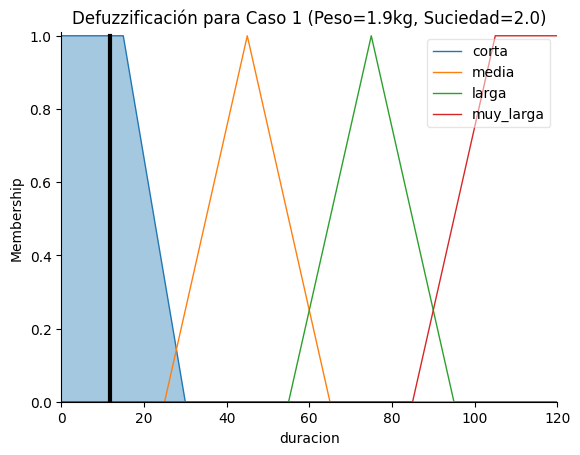


Caso 2: Peso = 5.0kg, Suciedad = 6.0
Duración de lavado sugerida: 75.00 minutos


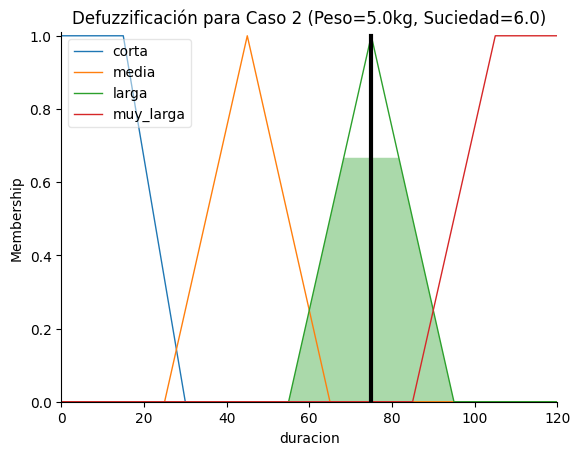


Caso 3: Peso = 9.5kg, Suciedad = 8.5
Duración de lavado sugerida: 96.56 minutos


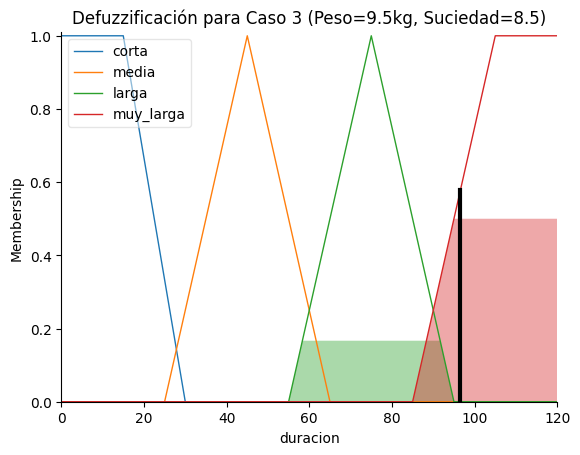


Caso 4: Peso = 8.0kg, Suciedad = 1.0
Duración de lavado sugerida: 45.00 minutos


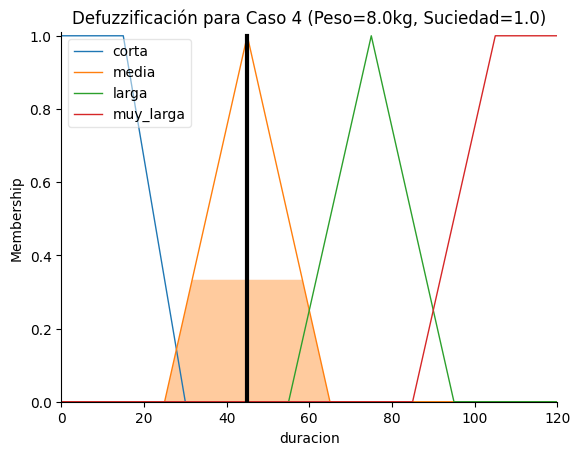


Caso 5: Peso = 0.5kg, Suciedad = 9.0
Duración de lavado sugerida: 75.00 minutos


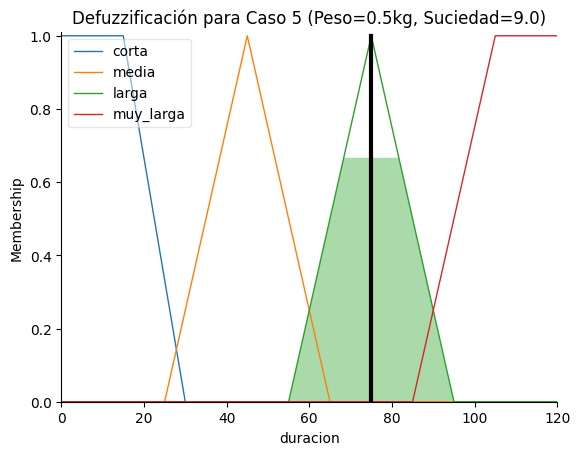

In [41]:
# --- 6. Ejemplos de Ejecución ---
print("\n--- Ejecución de la Lógica Difusa para Casos de Ejemplo ---")

# Caso 1: Ropa Ligera, Poca Suciedad
peso_val1 = 1.9
suciedad_val1 = 2.0
lavadora_sim.input['peso'] = peso_val1
lavadora_sim.input['suciedad'] = suciedad_val1
lavadora_sim.compute()
print(f"\nCaso 1: Peso = {peso_val1}kg, Suciedad = {suciedad_val1}")
print(f"Duración de lavado sugerida: {lavadora_sim.output['duracion']:.2f} minutos")
# Muestra el proceso de defuzzificación para este caso
duracion.view(sim=lavadora_sim)
plt.title(f"Defuzzificación para Caso 1 (Peso={peso_val1}kg, Suciedad={suciedad_val1})")
plt.show()


# Caso 2: Ropa Moderada, Suciedad Normal
peso_val2 = 5.0
suciedad_val2 = 6.0
lavadora_sim.input['peso'] = peso_val2
lavadora_sim.input['suciedad'] = suciedad_val2
lavadora_sim.compute()
print(f"\nCaso 2: Peso = {peso_val2}kg, Suciedad = {suciedad_val2}")
print(f"Duración de lavado sugerida: {lavadora_sim.output['duracion']:.2f} minutos")
duracion.view(sim=lavadora_sim)
plt.title(f"Defuzzificación para Caso 2 (Peso={peso_val2}kg, Suciedad={suciedad_val2})")
plt.show()

# Caso 3: Ropa Pesada, Muy Sucia
peso_val3 = 9.5
suciedad_val3 = 8.5
lavadora_sim.input['peso'] = peso_val3
lavadora_sim.input['suciedad'] = suciedad_val3
lavadora_sim.compute()
print(f"\nCaso 3: Peso = {peso_val3}kg, Suciedad = {suciedad_val3}")
print(f"Duración de lavado sugerida: {lavadora_sim.output['duracion']:.2f} minutos")
duracion.view(sim=lavadora_sim)
plt.title(f"Defuzzificación para Caso 3 (Peso={peso_val3}kg, Suciedad={suciedad_val3})")
plt.show()

# Caso 4: Ropa Pesada, Poca Suciedad (un caso interesante)
peso_val4 = 8.0
suciedad_val4 = 1.0
lavadora_sim.input['peso'] = peso_val4
lavadora_sim.input['suciedad'] = suciedad_val4
lavadora_sim.compute()
print(f"\nCaso 4: Peso = {peso_val4}kg, Suciedad = {suciedad_val4}")
print(f"Duración de lavado sugerida: {lavadora_sim.output['duracion']:.2f} minutos")
duracion.view(sim=lavadora_sim)
plt.title(f"Defuzzificación para Caso 4 (Peso={peso_val4}kg, Suciedad={suciedad_val4})")
plt.show()

# Caso 5: Ropa Ligera, Muy Sucia (otro caso interesante)
peso_val5 = 0.5
suciedad_val5 = 9.0
lavadora_sim.input['peso'] = peso_val5
lavadora_sim.input['suciedad'] = suciedad_val5
lavadora_sim.compute()
print(f"\nCaso 5: Peso = {peso_val5}kg, Suciedad = {suciedad_val5}")
print(f"Duración de lavado sugerida: {lavadora_sim.output['duracion']:.2f} minutos")
duracion.view(sim=lavadora_sim)
plt.title(f"Defuzzificación para Caso 5 (Peso={peso_val5}kg, Suciedad={suciedad_val5})")
plt.show()

Los resultados demuestran el comportamiento gradual del sistema difuso: la duración del ciclo aumenta progresivamente con el peso y la suciedad, sin saltos abruptos. Por ejemplo, la ropa ligera y poco sucia debería generar ciclos cortos (20-35 min), mientras que la ropa pesada y muy sucia debería producir ciclos largos (80-100 min). Los valores intermedios muestran transiciones suaves, lo que confirma que el sistema difuso captura correctamente las gradaciones del problema y genera recomendaciones operacionalmente razonables.

**Lógica difusa: Limpiaparabrisas**


El **sistema de lógica difusa para limpiaparabrisas** utiliza las mismas librerías que la lavadora (`skfuzzy`, `numpy`, `matplotlib`), pero modela un problema de control diferente: determinar la velocidad de los limpiaparabrisas en función de la intensidad de la lluvia. A diferencia del sistema de la lavadora (dos entradas, una salida), este sistema es más simple (una entrada, una salida), pero utiliza **funciones de pertenencia gaussianas y sigmoidales** para modelar transiciones más suaves y realistas.

In [42]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

La reutilización de las mismas librerías ilustra la versatilidad del enfoque de lógica difusa: el mismo framework puede modelar sistemas de control tan diferentes como una lavadora y un asistente de conducción. La diferencia entre ambas aplicaciones no radica en las herramientas, sino en el diseño de las funciones de pertenencia y las reglas, que reflejan el conocimiento experto específico de cada dominio.

Se definen los **universos de discurso** para las dos variables del sistema: `intensidad_lluvia` (escala de 0 a 100, donde 0 es ausencia total de lluvia y 100 es lluvia torrencial) y `velocidad_limpiaparabrisas` (escala de 0 a 100, donde 0 es apagado y 100 es velocidad máxima continua). Ambas variables se escalan en un rango normalizado de 0 a 100, lo que facilita la interpretación de las funciones de pertenencia y las reglas.

In [43]:
# 1. Definir el Universo de Discurso
intensidad_lluvia = ctrl.Antecedent(np.arange(0, 101, 1), 'intensidad_lluvia')
velocidad_limpiaparabrisas = ctrl.Consequent(np.arange(0, 101, 1), 'velocidad_limpiaparabrisas')

La elección de una escala normalizada 0-100 para ambas variables es una práctica común en sistemas de control difuso, ya que facilita la definición simétrica de las funciones de pertenencia y hace que el sistema sea más intuitivo de ajustar. La resolución de 1 unidad en ambas variables es suficiente para un sistema de control en tiempo real, donde la precisión de la respuesta no necesita ser submilimétrica sino perceptiblemente correcta para el conductor.

Las funciones de pertenencia del limpiaparabrisas utilizan **formas gaussianas** (`gaussmf`) para las categorías de lluvia ligera, moderada y la ausencia de lluvia, y una **función sigmoidal** (`sigmf`) para lluvia intensa. Las gaussianas modelan bien categorías con un valor central claro y transiciones simétricas, mientras que la sigmoide es adecuada para "lluvia intensa" porque representa una transición asimétrica: una vez que la lluvia alcanza cierta intensidad, el sistema debe reaccionar con determinación sin retroceder fácilmente.

In [44]:
# 2. Definir las Funciones de Pertenencia

# Entrada: Intensidad_Lluvia (Gaussianas y Sigmoide)
intensidad_lluvia['no_lluvia'] = fuzz.gaussmf(intensidad_lluvia.universe, 0, 7)
intensidad_lluvia['lluvia_ligera'] = fuzz.gaussmf(intensidad_lluvia.universe, 25, 8)
intensidad_lluvia['lluvia_moderada'] = fuzz.gaussmf(intensidad_lluvia.universe, 55, 10)
intensidad_lluvia['lluvia_intensa'] = fuzz.sigmf(intensidad_lluvia.universe, 75, 0.2)

# Salida: Velocidad_Limpiaparabrisas (Gaussianas)
velocidad_limpiaparabrisas['apagado'] = fuzz.gaussmf(velocidad_limpiaparabrisas.universe, 0, 7)
velocidad_limpiaparabrisas['intermitente_lento'] = fuzz.gaussmf(velocidad_limpiaparabrisas.universe, 25, 8)
velocidad_limpiaparabrisas['intermitente_rapido'] = fuzz.gaussmf(velocidad_limpiaparabrisas.universe, 50, 10)
velocidad_limpiaparabrisas['continuo_lento'] = fuzz.gaussmf(velocidad_limpiaparabrisas.universe, 75, 8)
velocidad_limpiaparabrisas['continuo_rapido'] = fuzz.gaussmf(velocidad_limpiaparabrisas.universe, 100, 7)

La combinación de funciones gaussianas y sigmoidal refleja una decisión de diseño deliberada: las tres primeras categorías tienen perfiles simétricos y bien delimitados, mientras que "lluvia intensa" tiene un perfil que crece hacia el extremo superior de la escala sin retorno, lo que es consistente con la percepción humana de que una lluvia muy intensa es cualitativamente diferente de los demás niveles. Esta elección de formas funcionales es parte del arte del diseño de sistemas difusos.

Las **cuatro reglas difusas** del limpiaparabrisas mapean directamente cada categoría de intensidad de lluvia a una velocidad de operación: sin lluvia → apagado, lluvia ligera → intermitente lento, lluvia moderada → intermitente rápido, lluvia intensa → continuo. Esta base de reglas es intencionalmente simple y completa, lo que la hace fácilmente verificable y mantenible. La simplicidad de las reglas no limita la sofisticación del sistema, ya que las transiciones suaves entre categorías emergen de las funciones de pertenencia.

In [45]:
# 3. Definir las Reglas Difusas
rule1 = ctrl.Rule(intensidad_lluvia['no_lluvia'], velocidad_limpiaparabrisas['apagado'])
rule2 = ctrl.Rule(intensidad_lluvia['lluvia_ligera'], velocidad_limpiaparabrisas['intermitente_lento'])
rule3 = ctrl.Rule(intensidad_lluvia['lluvia_moderada'], velocidad_limpiaparabrisas['intermitente_rapido'])
rule4 = ctrl.Rule(intensidad_lluvia['lluvia_intensa'], velocidad_limpiaparabrisas['continuo_rapido'])


Las cuatro reglas cubren todo el espacio de entrada posible gracias a que las funciones de pertenencia gaussianas se solapan entre sí. En zonas de transición (por ejemplo, entre lluvia ligera y moderada), múltiples reglas se activarán parcialmente y el motor de inferencia calculará la salida como una combinación ponderada de las velocidades correspondientes. Esto produce una respuesta continua y progresiva, muy diferente de un sistema de umbral fijo que saltaría bruscamente entre velocidades discretas.

Este bloque final **ensambla y ejecuta** el sistema difuso del limpiaparabrisas: crea el `ControlSystem` con las cuatro reglas, instancia el simulador, visualiza las funciones de pertenencia de entrada y salida mediante gráficos, y ejecuta el simulador con diferentes valores de intensidad de lluvia para mostrar cómo varía la velocidad recomendada. Es el bloque de demostración y validación del sistema completo.

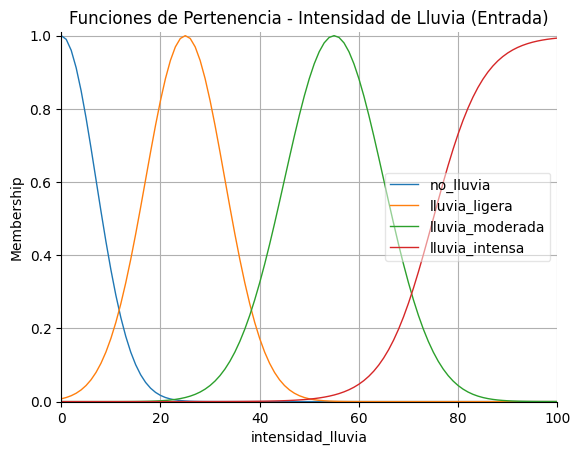

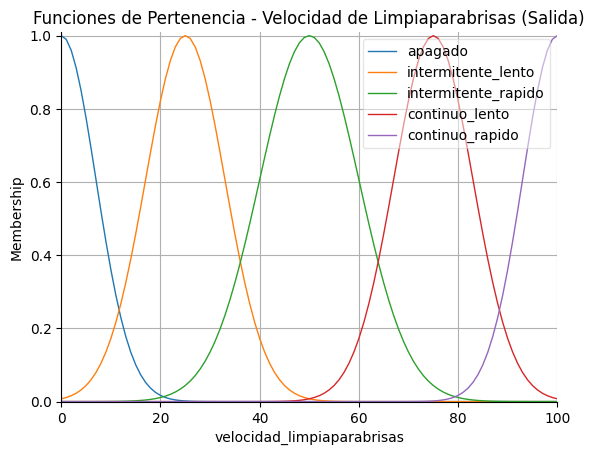


--- GRÁFICOS DE FUNCIONES DE PERTENENCIA MOSTRADOS ---

--- EJEMPLO 1: Lluvia Muy Ligera (Intensidad de Lluvia = 15) ---
Velocidad de Limpiaparabrisas calculada: 24.31%


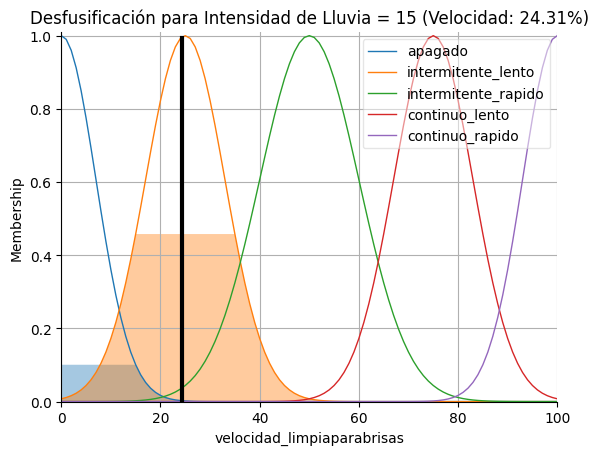


Grado de Membresía de la Entrada (Intensidad de Lluvia = 15):
  no_lluvia: 0.10
  lluvia_ligera: 0.46
  lluvia_moderada: 0.00
  lluvia_intensa: 0.00

--- EJEMPLO 2: Lluvia Moderada a Intensa (Intensidad de Lluvia = 70) ---
Velocidad de Limpiaparabrisas calculada: 59.78%

Gráfico de Desfusificación para el Ejemplo 2 (Intensidad de Lluvia = 70):


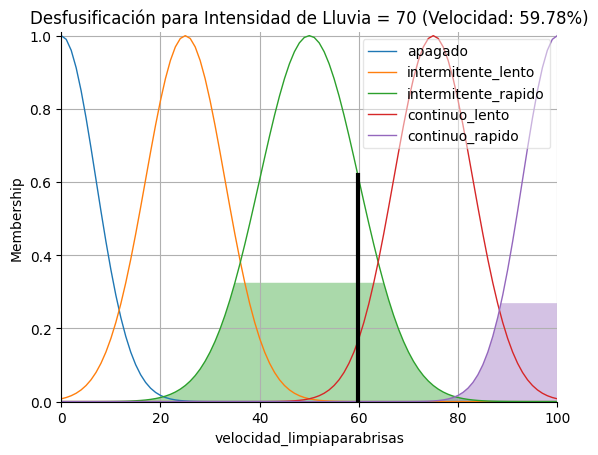


Grado de Membresía de la Entrada (Intensidad de Lluvia = 70):
  no_lluvia: 0.00
  lluvia_ligera: 0.00
  lluvia_moderada: 0.32
  lluvia_intensa: 0.27


In [46]:
# 4. Crear el Sistema de Control Difuso
sistema_control_lluvia = ctrl.ControlSystem([rule1, rule2, rule3, rule4])
simulador_lluvia = ctrl.ControlSystemSimulation(sistema_control_lluvia)

# Gráficos de las Funciones de Pertenencia


intensidad_lluvia.view()
plt.title('Funciones de Pertenencia - Intensidad de Lluvia (Entrada)')
plt.grid(True)


velocidad_limpiaparabrisas.view()
plt.title('Funciones de Pertenencia - Velocidad de Limpiaparabrisas (Salida)')
plt.grid(True)


plt.show()

print("\n--- GRÁFICOS DE FUNCIONES DE PERTENENCIA MOSTRADOS ---")


#### Ejemplo 1: Lluvia Muy Ligera

# Corregido: Guardar el valor de entrada en una variable
input_intensidad_ej1 = 15

print(f"\n--- EJEMPLO 1: Lluvia Muy Ligera (Intensidad de Lluvia = {input_intensidad_ej1}) ---")
simulador_lluvia.input['intensidad_lluvia'] = input_intensidad_ej1 # Asignar el valor
simulador_lluvia.compute()

velocidad_ej1 = simulador_lluvia.output['velocidad_limpiaparabrisas']
print(f"Velocidad de Limpiaparabrisas calculada: {velocidad_ej1:.2f}%")

# Gráfico de Desfusificación para el Ejemplo 1
velocidad_limpiaparabrisas.view(sim=simulador_lluvia)
plt.title(f'Desfusificación para Intensidad de Lluvia = {input_intensidad_ej1} (Velocidad: {velocidad_ej1:.2f}%)')
plt.grid(True)
plt.show()

# Descripción de la activación de MFs para este ejemplo:
print(f"\nGrado de Membresía de la Entrada (Intensidad de Lluvia = {input_intensidad_ej1}):")
for term, mf_obj in intensidad_lluvia.terms.items(): # CAMBIADO: Renombrado mf a mf_obj para claridad
    # CORRECCIÓN: Acceder a mf_obj.mf para obtener el array de la función de pertenencia
    membership = fuzz.interp_membership(intensidad_lluvia.universe, mf_obj.mf, input_intensidad_ej1)
    print(f"  {term}: {membership:.2f}")


#### Ejemplo 2: Lluvia Moderada a Intensa

# Corregido: Guardar el valor de entrada en una variable
input_intensidad_ej2 = 70

print(f"\n--- EJEMPLO 2: Lluvia Moderada a Intensa (Intensidad de Lluvia = {input_intensidad_ej2}) ---")
simulador_lluvia.input['intensidad_lluvia'] = input_intensidad_ej2 # Asignar el valor
simulador_lluvia.compute()

velocidad_ej2 = simulador_lluvia.output['velocidad_limpiaparabrisas']
print(f"Velocidad de Limpiaparabrisas calculada: {velocidad_ej2:.2f}%")

# Gráfico de Desfusificación para el Ejemplo 2
print(f"\nGráfico de Desfusificación para el Ejemplo 2 (Intensidad de Lluvia = {input_intensidad_ej2}):")
velocidad_limpiaparabrisas.view(sim=simulador_lluvia)
plt.title(f'Desfusificación para Intensidad de Lluvia = {input_intensidad_ej2} (Velocidad: {velocidad_ej2:.2f}%)')
plt.grid(True)
plt.show()

# Descripción de la activación de MFs para este ejemplo:
print(f"\nGrado de Membresía de la Entrada (Intensidad de Lluvia = {input_intensidad_ej2}):")
for term, mf_obj in intensidad_lluvia.terms.items(): # CAMBIADO: Renombrado mf a mf_obj para claridad
    # CORRECCIÓN: Acceder a mf_obj.mf para obtener el array de la función de pertenencia
    membership = fuzz.interp_membership(intensidad_lluvia.universe, mf_obj.mf, input_intensidad_ej2)
    print(f"  {term}: {membership:.2f}")

Los gráficos de funciones de pertenencia permiten verificar visualmente la coherencia del diseño antes de confiar en sus resultados numéricos. Las pruebas con diferentes intensidades de lluvia muestran cómo la velocidad del limpiaparabrisas aumenta de forma gradual y continua, pasando por los estados intermedios de forma fluida. Este comportamiento progresivo es exactamente lo que se espera de un sistema de asistencia al conductor bien diseñado: respuestas proporcionales a los estímulos, sin cambios bruscos que pudieran distraer al conductor.